# 4. Τελική Σύνθεση Αποτελεσμάτων και Ερμηνεία για την Πτυχιακή

Στο παρόν notebook πραγματοποιείται η τελική σύνθεση των αποτελεσμάτων της ανάλυσης της αγοράς μεταχειρισμένων αυτοκινήτων στην Αττική, καθώς και η ερμηνεία της απόδοσης των μοντέλων πρόβλεψης τιμής.

Στόχος της ενότητας είναι:

- η συγκεντρωτική παρουσίαση των αποτελεσμάτων των προηγούμενων notebooks,
- η τεκμηριωμένη επιλογή του τελικού μοντέλου,
- η ανάλυση της επίδρασης του hyperparameter tuning,
- η διερεύνηση της συμπεριφοράς του μοντέλου σε επιμέρους τμήματα της αγοράς,
- η παρουσίαση των βασικών ευρημάτων ερμηνευσιμότητας μέσω SHAP,
- και η διατύπωση συμπερασμάτων, περιορισμών και προτάσεων για μελλοντική έρευνα.

Το notebook βασίζεται αποκλειστικά στα exported αρχεία αποτελεσμάτων των προηγούμενων σταδίων, διασφαλίζοντας την αναπαραγωγιμότητα της ανάλυσης.

## Μεθοδολογικό Πλαίσιο

Η παρούσα ενότητα οργανώνεται στα ακόλουθα στάδια:

1. Φόρτωση των τελικών exported αρχείων αποτελεσμάτων.
2. Συνολική σύγκριση των βασικών μοντέλων πρόβλεψης.
3. Ανάλυση της επίδρασης του hyperparameter tuning.
4. Ανάλυση σφαλμάτων ανά price segment.
5. Ανάλυση σφαλμάτων ανά καύσιμο, έτος εγγραφής και κατασκευαστή.
6. Ερμηνεία του τελικού μοντέλου μέσω SHAP.
7. Σύνθεση των βασικών ευρημάτων σε thesis-ready πίνακες.
8. Διατύπωση τελικών συμπερασμάτων, περιορισμών και προτάσεων για μελλοντική έρευνα.

In [1]:
# ============================================================
# ΕΙΣΑΓΩΓΗ ΒΙΒΛΙΟΘΗΚΩΝ
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ============================================================
# ΒΑΣΙΚΕΣ ΡΥΘΜΙΣΕΙΣ ΠΑΡΟΥΣΙΑΣΗΣ
# ============================================================

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["figure.dpi"] = 120

In [4]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def find_project_root(start_path: Path) -> Path:
    """
    Εντοπίζει τον root φάκελο του project αναζητώντας το README.md.
    """
    start_path = start_path.resolve()

    for path in [start_path] + list(start_path.parents):
        if (path / "README.md").exists():
            return path

    raise FileNotFoundError("Δεν εντοπίστηκε ο root φάκελος του project.")


def find_first_existing_column(df: pd.DataFrame, candidate_names: list[str], df_name: str = "DataFrame") -> str:
    """
    Επιστρέφει το πρώτο όνομα στήλης που υπάρχει πραγματικά στο DataFrame.
    Χρήσιμο όταν τα exports έχουν μικρές διαφορές ονοματοδοσίας.
    """
    for col in candidate_names:
        if col in df.columns:
            return col

    raise KeyError(
        f"Δεν βρέθηκε καμία από τις στήλες {candidate_names} στο {df_name}. "
        f"Διαθέσιμες στήλες: {df.columns.tolist()}"
    )


def save_current_plot(output_path: Path) -> None:
    """
    Αποθηκεύει το τρέχον plot σε αρχείο PNG.
    """
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight")
    print(f"✅ Το plot αποθηκεύτηκε: {output_path}")


def safe_round_columns(df: pd.DataFrame, columns: list[str], decimals: int = 2) -> pd.DataFrame:
    """
    Κάνει round μόνο στις στήλες που υπάρχουν.
    """
    out = df.copy()
    for col in columns:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce").round(decimals)
    return out


def display_title(title: str) -> None:
    """
    Εκτυπώνει έναν μικρό τίτλο μέσα στο notebook για οπτική οργάνωση.
    """
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

## Ορισμός Διαδρομών και Φακέλων Εξαγωγής

Στο σημείο αυτό ορίζονται οι βασικοί φάκελοι του project, καθώς και οι κατάλληλες διαδρομές για:

- τα exported αποτελέσματα από το `data/processed/`,
- τα figures που θα εξαχθούν στο `plots/`,
- και τους τελικούς summary πίνακες που θα χρησιμοποιηθούν στη συγγραφή της πτυχιακής.

In [5]:
# ============================================================
# PATHS ΤΟΥ PROJECT
# ============================================================

PROJECT_ROOT = find_project_root(Path.cwd())

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PLOTS_DIR = PROJECT_ROOT / "plots"
NOTEBOOK4_TABLES_DIR = DATA_PROCESSED_DIR / "notebook4_outputs"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK4_TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data dir:", DATA_PROCESSED_DIR)
print("Plots dir:", PLOTS_DIR)
print("Notebook 4 outputs dir:", NOTEBOOK4_TABLES_DIR)

Project root: C:\Users\athin\Desktop\Car-Market-Analysis-Attica
Processed data dir: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed
Plots dir: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots
Notebook 4 outputs dir: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook4_outputs


## Φόρτωση των Exported Αρχείων Αποτελεσμάτων

Στην παρούσα φάση φορτώνονται τα βασικά αρχεία που προέκυψαν από τα προηγούμενα στάδια της ανάλυσης. Τα αρχεία αυτά αποτελούν τη βάση για τη σύνθεση των τελικών ευρημάτων.

Ειδικότερα, χρησιμοποιούνται:

- τα αποτελέσματα της αρχικής σύγκρισης μοντέλων,
- τα τελικά test-set αποτελέσματα από το Notebook 3,
- η σύγκριση tuned και untuned μοντέλων,
- η ανάλυση σφαλμάτων ανά κατηγορία,
- και τα αποτελέσματα grouped SHAP importance.

In [7]:
# ============================================================
# ΦΟΡΤΩΣΗ ΑΡΧΕΙΩΝ
# ============================================================

model_comparison_df = pd.read_csv(DATA_PROCESSED_DIR / "model_comparison_results.csv")
best_predictions_df = pd.read_csv(DATA_PROCESSED_DIR / "best_model_test_predictions.csv")

nb3_results_df = pd.read_csv(DATA_PROCESSED_DIR / "notebook3_model_test_results.csv")
nb3_tuning_df = pd.read_csv(DATA_PROCESSED_DIR / "notebook3_tuned_vs_untuned_comparison.csv")
nb3_final_preds_df = pd.read_csv(DATA_PROCESSED_DIR / "notebook3_final_model_predictions.csv")

error_fuel_df = pd.read_csv(DATA_PROCESSED_DIR / "notebook3_error_by_fuel_type.csv")
error_make_df = pd.read_csv(DATA_PROCESSED_DIR / "notebook3_error_by_make.csv")
error_year_df = pd.read_csv(DATA_PROCESSED_DIR / "notebook3_error_by_registration_year.csv")
error_segment_df = pd.read_csv(DATA_PROCESSED_DIR / "notebook3_error_by_price_segment.csv")

shap_grouped_df = pd.read_csv(DATA_PROCESSED_DIR / "notebook3_grouped_shap_importance.csv")

print("Όλα τα βασικά exported αρχεία φορτώθηκαν επιτυχώς.")

Όλα τα βασικά exported αρχεία φορτώθηκαν επιτυχώς.


In [8]:
# ============================================================
# ΓΡΗΓΟΡΟΣ ΕΛΕΓΧΟΣ ΔΙΑΣΤΑΣΕΩΝ
# ============================================================

loaded_tables = {
    "model_comparison_df": model_comparison_df,
    "best_predictions_df": best_predictions_df,
    "nb3_results_df": nb3_results_df,
    "nb3_tuning_df": nb3_tuning_df,
    "nb3_final_preds_df": nb3_final_preds_df,
    "error_fuel_df": error_fuel_df,
    "error_make_df": error_make_df,
    "error_year_df": error_year_df,
    "error_segment_df": error_segment_df,
    "shap_grouped_df": shap_grouped_df,
}

shape_summary_df = pd.DataFrame({
    "Table": list(loaded_tables.keys()),
    "Rows": [df.shape[0] for df in loaded_tables.values()],
    "Columns": [df.shape[1] for df in loaded_tables.values()],
})

shape_summary_df

,Table,Rows,Columns
0,model_comparison_df,5,4
1,best_predictions_df,1660,3
2,nb3_results_df,4,10
3,nb3_tuning_df,2,9
4,nb3_final_preds_df,1660,18
5,error_fuel_df,7,10
6,error_make_df,23,10
7,error_year_df,5,10
8,error_segment_df,5,10
9,shap_grouped_df,9,2


In [9]:
# ============================================================
# ΠΡΟΒΟΛΗ ΣΤΗΛΩΝ ΓΙΑ ΕΠΙΒΕΒΑΙΩΣΗ
# ============================================================

for name, df in loaded_tables.items():
    display_title(f"Στήλες του {name}")
    print(df.columns.tolist())


Στήλες του model_comparison_df
['Μοντέλο', 'MAE', 'RMSE', 'R2']

Στήλες του best_predictions_df
['Actual_Price', 'Predicted_Price', 'Residual']

Στήλες του nb3_results_df
['Model', 'Model_Family', 'Tuning_Status', 'CV_Best_RMSE', 'MAE', 'RMSE', 'R2', 'MedAE', 'Bias', 'MAPE_%']

Στήλες του nb3_tuning_df
['Model_Family', 'Untuned_RMSE', 'Tuned_RMSE', 'ΔRMSE_(Tuned-Untuned)', 'RMSE_Improvement_%', 'Untuned_MAE', 'Tuned_MAE', 'ΔMAE_(Tuned-Untuned)', 'MAE_Improvement_%']

Στήλες του nb3_final_preds_df
['Κατασκευαστής', 'Τύπος', 'Εγγραφή', 'Καύσιμο', 'Μετάδοση', 'Περιοχή', 'Ηλικία', 'Κυβικά', 'Ιπποδύναμη', 'Χιλιόμετρα', 'Actual_Price', 'Predicted_Price', 'Residual', 'Absolute_Error', 'Squared_Error', 'Absolute_Percentage_Error_%', 'Residual_Sign', 'Price_Segment']

Στήλες του error_fuel_df
['Καύσιμο', 'Count', 'Mean_Actual_Price', 'Mean_Predicted_Price', 'MAE', 'RMSE', 'R2', 'MedAE', 'Bias', 'MAPE_%']

Στήλες του error_make_df
['Κατασκευαστής', 'Count', 'Mean_Actual_Price', 'Mean_Predicted_

## Συνολική Σύγκριση των Βασικών Μοντέλων

Στο πρώτο στάδιο της σύνθεσης παρουσιάζεται η συνολική σύγκριση των βασικών μοντέλων που αξιολογήθηκαν για την πρόβλεψη της τιμής.

Οι βασικές μετρικές που χρησιμοποιούνται είναι:

- **MAE (Mean Absolute Error)**,
- **RMSE (Root Mean Squared Error)**,
- **R² (Coefficient of Determination)**.

Η μετρική **RMSE** αποκτά ιδιαίτερη σημασία, καθώς τιμωρεί περισσότερο τα μεγάλα σφάλματα πρόβλεψης και είναι συνεπώς ιδιαίτερα χρήσιμη στην αποτίμηση οχημάτων, όπου οι μεγάλες αποκλίσεις έχουν αυξημένη πρακτική σημασία.

In [10]:
# ============================================================
# ΕΝΤΟΠΙΣΜΟΣ ΣΤΗΛΩΝ ΓΙΑ ΤΗΝ ΑΡΧΙΚΗ ΣΥΓΚΡΙΣΗ ΜΟΝΤΕΛΩΝ
# ============================================================

mc_model_col = find_first_existing_column(model_comparison_df, ["Μοντέλο", "Model"], "model_comparison_df")
mc_mae_col = find_first_existing_column(model_comparison_df, ["MAE"], "model_comparison_df")
mc_rmse_col = find_first_existing_column(model_comparison_df, ["RMSE"], "model_comparison_df")
mc_r2_col = find_first_existing_column(model_comparison_df, ["R2", "R²"], "model_comparison_df")

model_comparison_display = model_comparison_df[[mc_model_col, mc_mae_col, mc_rmse_col, mc_r2_col]].copy()
model_comparison_display = model_comparison_display.rename(columns={
    mc_model_col: "Μοντέλο",
    mc_mae_col: "MAE",
    mc_rmse_col: "RMSE",
    mc_r2_col: "R²"
})
model_comparison_display = safe_round_columns(model_comparison_display, ["MAE", "RMSE"], 2)
if "R²" in model_comparison_display.columns:
    model_comparison_display["R²"] = pd.to_numeric(model_comparison_display["R²"], errors="coerce").round(4)

model_comparison_display = model_comparison_display.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

model_comparison_display

,Μοντέλο,MAE,RMSE,R²
0,XGBoost,"4,089.6600","7,587.2500",0.9417
1,RandomForest,"3,855.4200","8,159.8600",0.9326
2,Ridge,"5,670.6700","9,988.7000",0.8990
3,LinearRegression,"5,301.6800","10,312.9500",0.8923
4,DummyRegressor,"16,831.9200","33,345.8900",-0.1261


In [11]:
# ============================================================
# ΑΠΟΘΗΚΕΥΣΗ ΠΙΝΑΚΑ ΣΥΓΚΡΙΣΗΣ ΜΟΝΤΕΛΩΝ
# ============================================================

model_comparison_display.to_csv(
    NOTEBOOK4_TABLES_DIR / "notebook4_model_comparison_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Αποθηκεύτηκε ο πίνακας σύγκρισης μοντέλων.")

Αποθηκεύτηκε ο πίνακας σύγκρισης μοντέλων.


✅ Το plot αποθηκεύτηκε: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook4_model_comparison_rmse.png


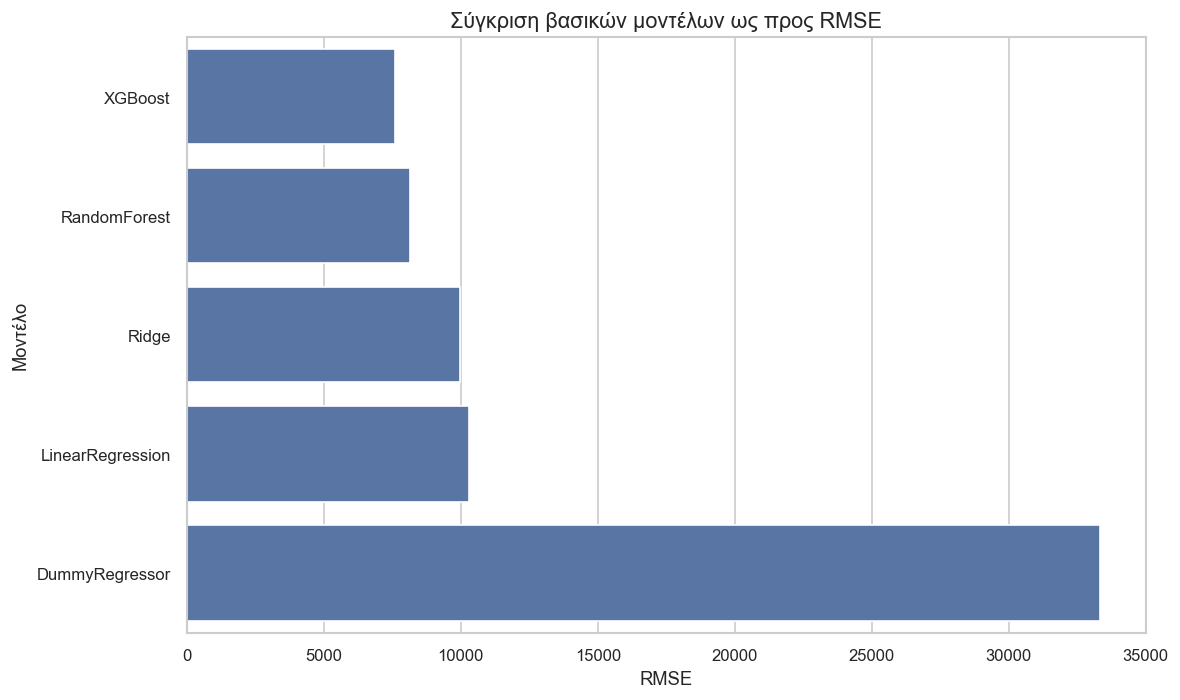

In [12]:
# ============================================================
# PLOT: ΣΥΓΚΡΙΣΗ ΜΟΝΤΕΛΩΝ ΩΣ ΠΡΟΣ RMSE
# ============================================================

plt.figure(figsize=(10, 6))
sns.barplot(data=model_comparison_display, x="RMSE", y="Μοντέλο")
plt.title("Σύγκριση βασικών μοντέλων ως προς RMSE")
plt.xlabel("RMSE")
plt.ylabel("Μοντέλο")

save_current_plot(PLOTS_DIR / "notebook4_model_comparison_rmse.png")
plt.show()

✅ Το plot αποθηκεύτηκε: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook4_model_comparison_mae.png


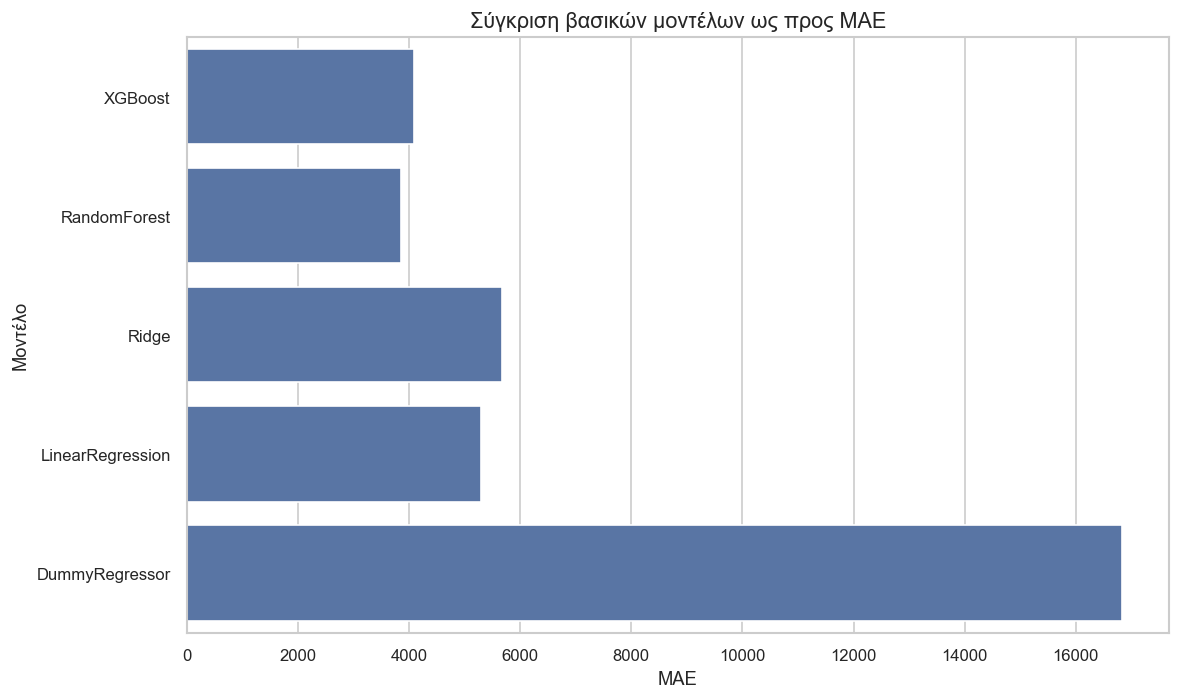

In [13]:
# ============================================================
# PLOT: ΣΥΓΚΡΙΣΗ ΜΟΝΤΕΛΩΝ ΩΣ ΠΡΟΣ MAE
# ============================================================

plt.figure(figsize=(10, 6))
sns.barplot(data=model_comparison_display, x="MAE", y="Μοντέλο")
plt.title("Σύγκριση βασικών μοντέλων ως προς MAE")
plt.xlabel("MAE")
plt.ylabel("Μοντέλο")

save_current_plot(PLOTS_DIR / "notebook4_model_comparison_mae.png")
plt.show()

### Ερμηνεία της αρχικής σύγκρισης μοντέλων

Η αρχική συγκριτική αξιολόγηση δείχνει ότι τα ensemble tree-based μοντέλα υπερέχουν σαφώς των απλούστερων baseline και γραμμικών προσεγγίσεων.

Ειδικότερα:

- τα μοντέλα **Random Forest** και **XGBoost** επιτυγχάνουν αισθητά χαμηλότερα σφάλματα,
- ενώ τα γραμμικά μοντέλα εμφανίζουν περιορισμένη ικανότητα αποτύπωσης της πολυπλοκότητας της αγοράς μεταχειρισμένων αυτοκινήτων.

Το αποτέλεσμα αυτό είναι αναμενόμενο, καθώς η τιμή ενός μεταχειρισμένου οχήματος επηρεάζεται από μη γραμμικές σχέσεις και αλληλεπιδράσεις μεταξύ πολλών χαρακτηριστικών, όπως η ηλικία, τα χιλιόμετρα, ο κατασκευαστής, ο τύπος καυσίμου και τα τεχνικά χαρακτηριστικά του οχήματος.

## Τελική Σύγκριση Μοντέλων από το Notebook 3

Στην παρούσα ενότητα παρουσιάζονται τα τελικά test-set αποτελέσματα των βασικών tree-based μοντέλων, τόσο στις untuned όσο και στις tuned εκδοχές τους.

Η σύγκριση αυτή είναι ιδιαίτερα σημαντική, καθώς επιτρέπει:

- την τελική αξιολόγηση της προγνωστικής ικανότητας των μοντέλων,
- τη σύγκριση μεταξύ tuned και untuned εκδόσεων,
- και την τεκμηριωμένη επιλογή του μοντέλου που θα χρησιμοποιηθεί ως τελικό μοντέλο της μελέτης.

In [14]:
# ============================================================
# ΕΝΤΟΠΙΣΜΟΣ ΣΤΗΛΩΝ ΣΤΑ ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ NOTEBOOK 3
# ============================================================

nb3_model_col = find_first_existing_column(nb3_results_df, ["Model", "Μοντέλο"], "nb3_results_df")
nb3_family_col = find_first_existing_column(nb3_results_df, ["Model_Family", "Family"], "nb3_results_df")
nb3_tuning_status_col = find_first_existing_column(nb3_results_df, ["Tuning_Status", "Tuning"], "nb3_results_df")
nb3_mae_col = find_first_existing_column(nb3_results_df, ["MAE"], "nb3_results_df")
nb3_medae_col = find_first_existing_column(nb3_results_df, ["MedAE", "MedianAE"], "nb3_results_df")
nb3_rmse_col = find_first_existing_column(nb3_results_df, ["RMSE"], "nb3_results_df")
nb3_r2_col = find_first_existing_column(nb3_results_df, ["R2", "R²"], "nb3_results_df")
nb3_mape_col = find_first_existing_column(nb3_results_df, ["MAPE_%", "MAPE"], "nb3_results_df")

nb3_results_display = nb3_results_df[
    [nb3_model_col, nb3_family_col, nb3_tuning_status_col, nb3_mae_col, nb3_medae_col, nb3_rmse_col, nb3_r2_col, nb3_mape_col]
].copy()

nb3_results_display = nb3_results_display.rename(columns={
    nb3_model_col: "Μοντέλο",
    nb3_family_col: "Οικογένεια Μοντέλου",
    nb3_tuning_status_col: "Κατάσταση Tuning",
    nb3_mae_col: "MAE",
    nb3_medae_col: "MedAE",
    nb3_rmse_col: "RMSE",
    nb3_r2_col: "R²",
    nb3_mape_col: "MAPE (%)"
})

nb3_results_display = safe_round_columns(nb3_results_display, ["MAE", "MedAE", "RMSE", "MAPE (%)"], 2)
nb3_results_display["R²"] = pd.to_numeric(nb3_results_display["R²"], errors="coerce").round(4)

nb3_results_display = nb3_results_display.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

nb3_results_display

,Μοντέλο,Οικογένεια Μοντέλου,Κατάσταση Tuning,MAE,MedAE,RMSE,R²,MAPE (%)
0,XGBoost_untuned,XGBoost,Untuned,"4,089.6600","2,163.8600","7,587.2500",0.9417,12.4200
1,XGBoost_tuned,XGBoost,Tuned,"3,832.8600","1,921.1500","7,700.5700",0.9399,11.0800
2,RandomForest_untuned,RandomForest,Untuned,"3,855.4200","1,631.7700","8,159.8600",0.9326,10.6000
3,RandomForest_tuned,RandomForest,Tuned,"3,832.1500","1,533.3800","8,202.3100",0.9319,10.4900


In [15]:
# ============================================================
# ΑΠΟΘΗΚΕΥΣΗ ΤΕΛΙΚΟΥ ΠΙΝΑΚΑ ΑΠΟΤΕΛΕΣΜΑΤΩΝ
# ============================================================

nb3_results_display.to_csv(
    NOTEBOOK4_TABLES_DIR / "notebook4_final_model_results_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Αποθηκεύτηκε ο τελικός πίνακας αποτελεσμάτων μοντέλων.")

Αποθηκεύτηκε ο τελικός πίνακας αποτελεσμάτων μοντέλων.


✅ Το plot αποθηκεύτηκε: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook4_final_models_rmse.png


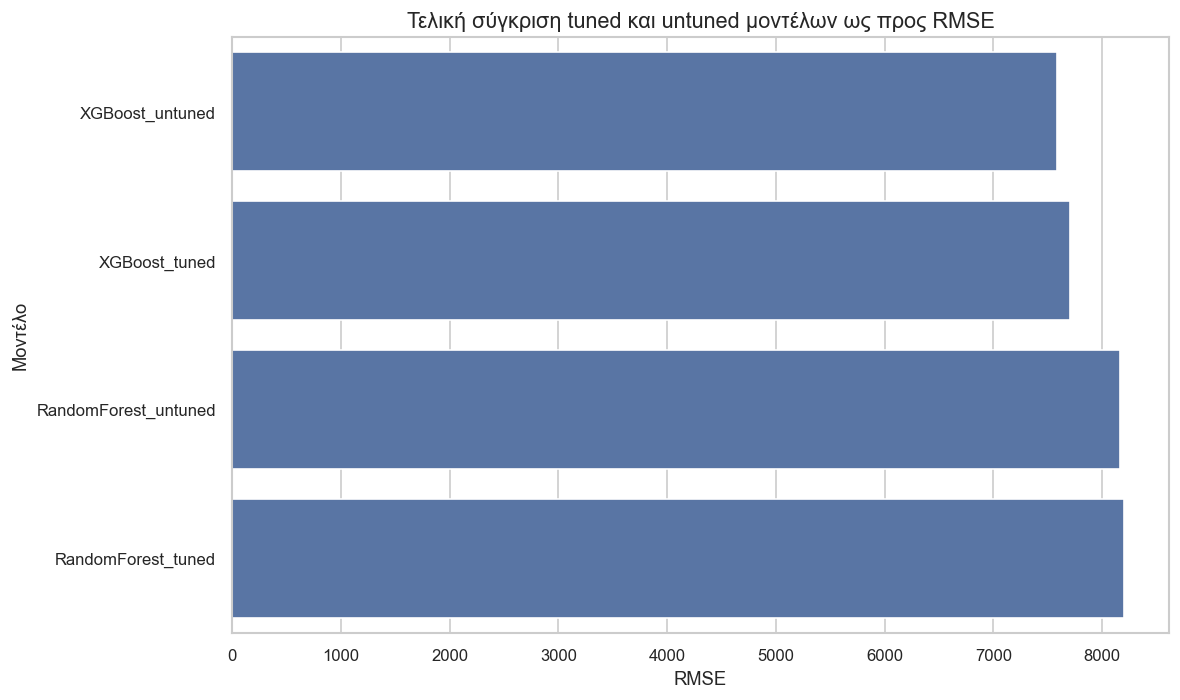

In [16]:
# ============================================================
# PLOT: ΤΕΛΙΚΗ ΣΥΓΚΡΙΣΗ ΜΟΝΤΕΛΩΝ ΩΣ ΠΡΟΣ RMSE
# ============================================================

plt.figure(figsize=(10, 6))
sns.barplot(data=nb3_results_display, x="RMSE", y="Μοντέλο")
plt.title("Τελική σύγκριση tuned και untuned μοντέλων ως προς RMSE")
plt.xlabel("RMSE")
plt.ylabel("Μοντέλο")

save_current_plot(PLOTS_DIR / "notebook4_final_models_rmse.png")
plt.show()

✅ Το plot αποθηκεύτηκε: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook4_final_models_r2.png


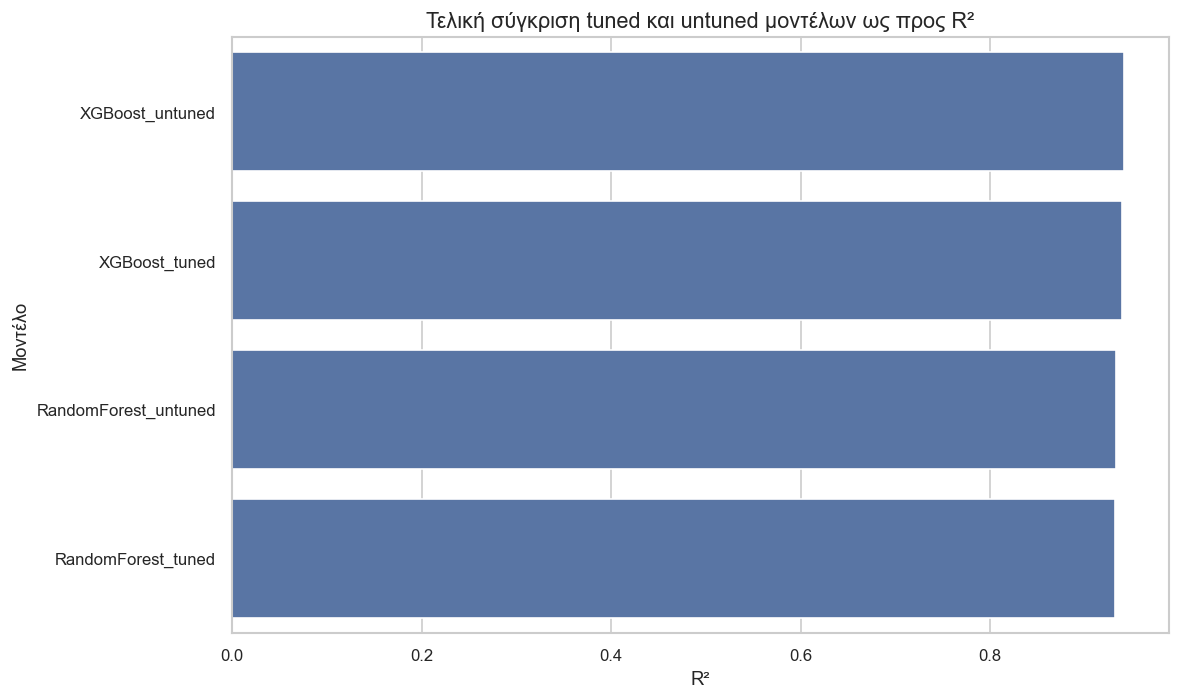

In [17]:
# ============================================================
# PLOT: ΤΕΛΙΚΗ ΣΥΓΚΡΙΣΗ ΜΟΝΤΕΛΩΝ ΩΣ ΠΡΟΣ R²
# ============================================================

plt.figure(figsize=(10, 6))
sns.barplot(data=nb3_results_display.sort_values(by="R²", ascending=False), x="R²", y="Μοντέλο")
plt.title("Τελική σύγκριση tuned και untuned μοντέλων ως προς R²")
plt.xlabel("R²")
plt.ylabel("Μοντέλο")

save_current_plot(PLOTS_DIR / "notebook4_final_models_r2.png")
plt.show()

### Ερμηνεία της τελικής σύγκρισης

Τα αποτελέσματα του τελικού σταδίου αξιολόγησης δείχνουν ότι το **untuned XGBoost** διατηρεί την καλύτερη συνολική επίδοση ως προς τη βασική μετρική **RMSE**, καθώς και πολύ υψηλή τιμή **R²**.

Το εύρημα αυτό υποδηλώνει ότι το συγκεκριμένο μοντέλο:

- αποτυπώνει με μεγαλύτερη επιτυχία τη μη γραμμική δομή των δεδομένων,
- παρουσιάζει ισχυρή ικανότητα γενίκευσης στο test set,
- και αποτελεί την πιο κατάλληλη επιλογή ως τελικό μοντέλο πρόβλεψης τιμής.

Παράλληλα, το Random Forest εμφανίζει επίσης ιδιαίτερα ισχυρή απόδοση, γεγονός που επιβεβαιώνει ότι οι ensemble μέθοδοι είναι καταλληλότερες για το συγκεκριμένο πρόβλημα σε σχέση με απλούστερες προσεγγίσεις.

## Ανάλυση της Επίδρασης του Hyperparameter Tuning

Στην παρούσα ενότητα εξετάζεται η επίδραση της διαδικασίας hyperparameter tuning στην απόδοση των βασικών tree-based μοντέλων.

Το σχετικό exported αρχείο δεν αποθηκεύει τα αποτελέσματα σε μορφή ξεχωριστών γραμμών για tuned και untuned μοντέλα, αλλά σε συγκεντρωτική μορφή ανά οικογένεια μοντέλου. Συνεπώς, η σύγκριση πραγματοποιείται απευθείας μεταξύ των μετρικών των untuned και tuned εκδοχών κάθε μοντέλου.

In [19]:
# ============================================================
# ΠΙΝΑΚΑΣ ΣΥΓΚΡΙΣΗΣ TUNED VS UNTUNED (WIDE FORMAT)
# ============================================================

tuning_family_col = find_first_existing_column(
    nb3_tuning_df,
    ["Model_Family", "Model", "Μοντέλο"],
    "nb3_tuning_df"
)

untuned_rmse_col = find_first_existing_column(
    nb3_tuning_df,
    ["Untuned_RMSE"],
    "nb3_tuning_df"
)

tuned_rmse_col = find_first_existing_column(
    nb3_tuning_df,
    ["Tuned_RMSE"],
    "nb3_tuning_df"
)

delta_rmse_col = find_first_existing_column(
    nb3_tuning_df,
    ["ΔRMSE_(Tuned-Untuned)", "Delta_RMSE", "RMSE_Difference"],
    "nb3_tuning_df"
)

rmse_improvement_col = find_first_existing_column(
    nb3_tuning_df,
    ["RMSE_Improvement_%", "RMSE_Improvement"],
    "nb3_tuning_df"
)

untuned_mae_col = find_first_existing_column(
    nb3_tuning_df,
    ["Untuned_MAE"],
    "nb3_tuning_df"
)

tuned_mae_col = find_first_existing_column(
    nb3_tuning_df,
    ["Tuned_MAE"],
    "nb3_tuning_df"
)

delta_mae_col = find_first_existing_column(
    nb3_tuning_df,
    ["ΔMAE_(Tuned-Untuned)", "Delta_MAE", "MAE_Difference"],
    "nb3_tuning_df"
)

mae_improvement_col = find_first_existing_column(
    nb3_tuning_df,
    ["MAE_Improvement_%", "MAE_Improvement"],
    "nb3_tuning_df"
)

tuning_display = nb3_tuning_df[
    [
        tuning_family_col,
        untuned_rmse_col,
        tuned_rmse_col,
        delta_rmse_col,
        rmse_improvement_col,
        untuned_mae_col,
        tuned_mae_col,
        delta_mae_col,
        mae_improvement_col,
    ]
].copy()

tuning_display = tuning_display.rename(columns={
    tuning_family_col: "Οικογένεια Μοντέλου",
    untuned_rmse_col: "Untuned RMSE",
    tuned_rmse_col: "Tuned RMSE",
    delta_rmse_col: "ΔRMSE (Tuned-Untuned)",
    rmse_improvement_col: "RMSE Improvement (%)",
    untuned_mae_col: "Untuned MAE",
    tuned_mae_col: "Tuned MAE",
    delta_mae_col: "ΔMAE (Tuned-Untuned)",
    mae_improvement_col: "MAE Improvement (%)",
})

# Στρογγυλοποίηση αριθμητικών στηλών για καθαρότερη παρουσίαση
numeric_cols = [
    "Untuned RMSE",
    "Tuned RMSE",
    "ΔRMSE (Tuned-Untuned)",
    "RMSE Improvement (%)",
    "Untuned MAE",
    "Tuned MAE",
    "ΔMAE (Tuned-Untuned)",
    "MAE Improvement (%)",
]

for col in numeric_cols:
    tuning_display[col] = pd.to_numeric(tuning_display[col], errors="coerce").round(2)

tuning_display

,Οικογένεια Μοντέλου,Untuned RMSE,Tuned RMSE,ΔRMSE (Tuned-Untuned),RMSE Improvement (%),Untuned MAE,Tuned MAE,ΔMAE (Tuned-Untuned),MAE Improvement (%)
0,RandomForest,"8,159.8600","8,202.3100",42.4500,-0.5200,"3,855.4200","3,832.1500",-23.2600,0.6000
1,XGBoost,"7,587.2500","7,700.5700",113.3200,-1.4900,"4,089.6600","3,832.8600",-256.7900,6.2800


In [20]:
# ============================================================
# ΑΠΟΘΗΚΕΥΣΗ ΠΙΝΑΚΑ TUNING
# ============================================================

tuning_display.to_csv(
    NOTEBOOK4_TABLES_DIR / "notebook4_tuned_vs_untuned_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Αποθηκεύτηκε ο πίνακας tuned vs untuned.")

Αποθηκεύτηκε ο πίνακας tuned vs untuned.


✅ Το plot αποθηκεύτηκε: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook4_tuning_rmse_comparison.png


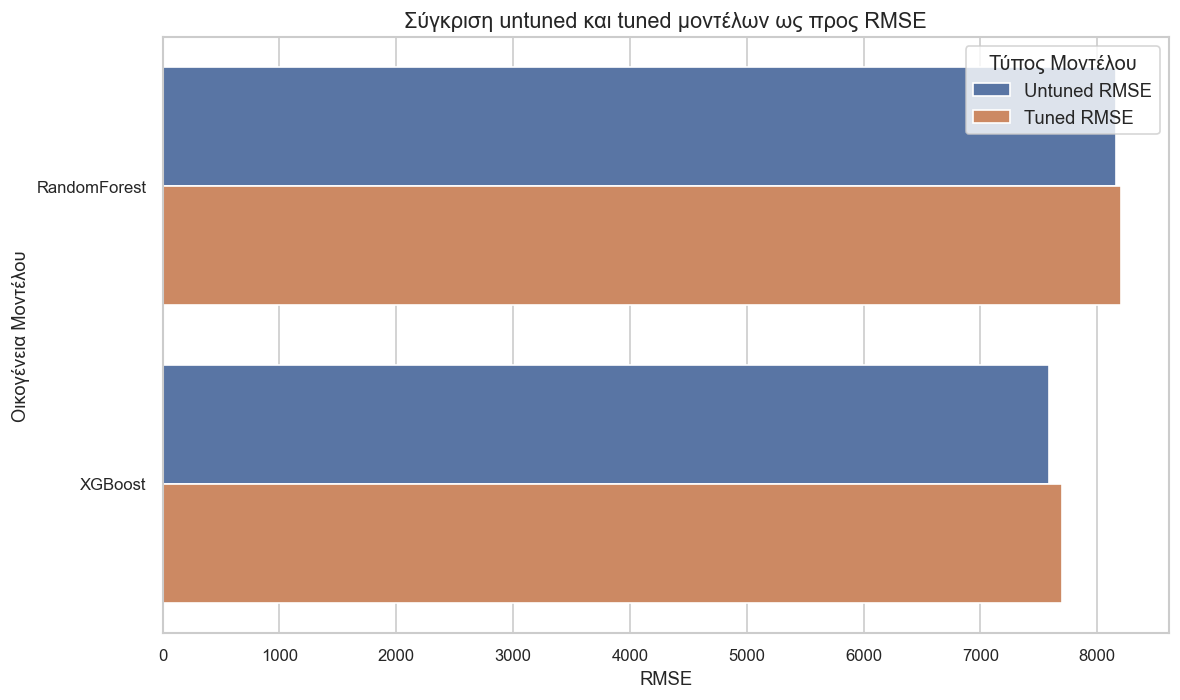

In [21]:
# ============================================================
# PLOT: ΣΥΓΚΡΙΣΗ UNTUNED VS TUNED RMSE
# ============================================================

tuning_rmse_plot_df = tuning_display.melt(
    id_vars="Οικογένεια Μοντέλου",
    value_vars=["Untuned RMSE", "Tuned RMSE"],
    var_name="Τύπος Μοντέλου",
    value_name="RMSE"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=tuning_rmse_plot_df, x="RMSE", y="Οικογένεια Μοντέλου", hue="Τύπος Μοντέλου")
plt.title("Σύγκριση untuned και tuned μοντέλων ως προς RMSE")
plt.xlabel("RMSE")
plt.ylabel("Οικογένεια Μοντέλου")

save_current_plot(PLOTS_DIR / "notebook4_tuning_rmse_comparison.png")
plt.show()

✅ Το plot αποθηκεύτηκε: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook4_tuning_mae_comparison.png


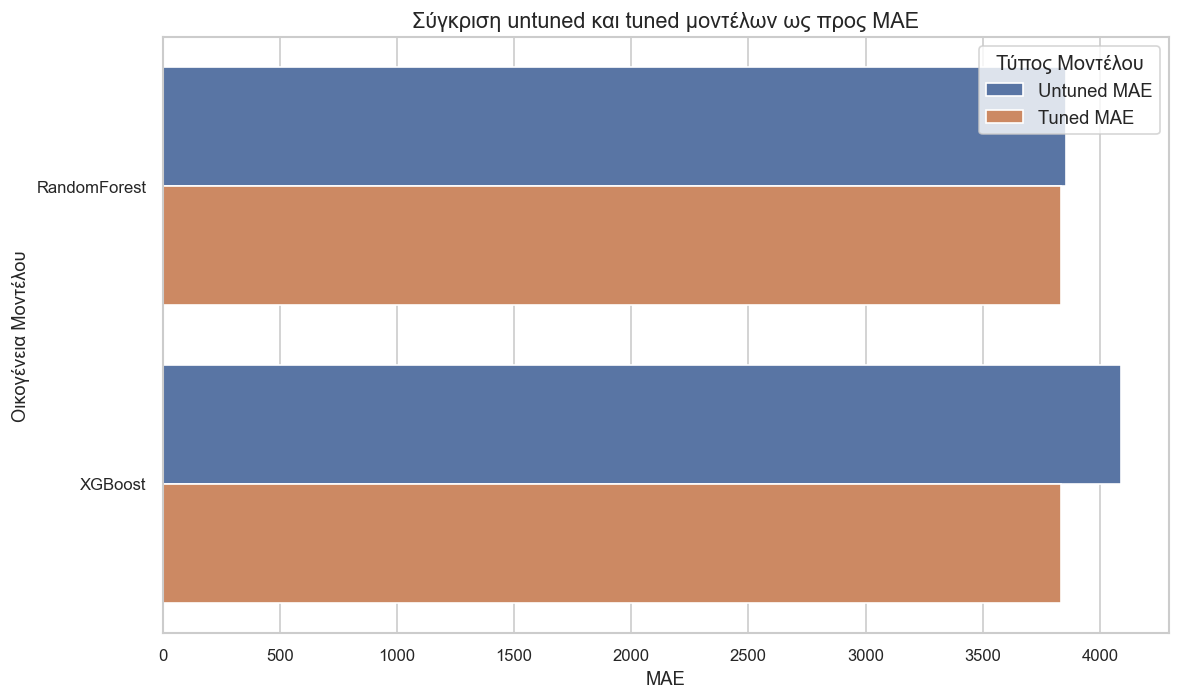

In [22]:
# ============================================================
# PLOT: ΣΥΓΚΡΙΣΗ UNTUNED VS TUNED MAE
# ============================================================

tuning_mae_plot_df = tuning_display.melt(
    id_vars="Οικογένεια Μοντέλου",
    value_vars=["Untuned MAE", "Tuned MAE"],
    var_name="Τύπος Μοντέλου",
    value_name="MAE"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=tuning_mae_plot_df, x="MAE", y="Οικογένεια Μοντέλου", hue="Τύπος Μοντέλου")
plt.title("Σύγκριση untuned και tuned μοντέλων ως προς MAE")
plt.xlabel("MAE")
plt.ylabel("Οικογένεια Μοντέλου")

save_current_plot(PLOTS_DIR / "notebook4_tuning_mae_comparison.png")
plt.show()

### Ερμηνεία της επίδρασης του tuning

Η σύγκριση μεταξύ untuned και tuned εκδόσεων δείχνει ότι η επίδραση του hyperparameter tuning είναι μικτή και εξαρτάται από τη μετρική αξιολόγησης.

Ειδικότερα:

- ως προς το **RMSE**, το tuning δεν οδήγησε σε βελτίωση της συνολικής προγνωστικής επίδοσης,
- ενώ ως προς το **MAE** καταγράφονται σε ορισμένες περιπτώσεις μικρές βελτιώσεις.

Το εύρημα αυτό υποδηλώνει ότι τα αρχικά μοντέλα ήταν ήδη αρκετά ισχυρά και ότι η περαιτέρω βελτιστοποίηση δεν βελτίωσε ουσιαστικά τη γενίκευση στο test set.

Συνεπώς, η τελική αξιολόγηση δεν πρέπει να βασίζεται αποκλειστικά στην ύπαρξη tuning, αλλά στη συνολική συμπεριφορά του μοντέλου ως προς πολλαπλές μετρικές.

## Ανάλυση Σφαλμάτων Ανά Price Segment

Η ανάλυση σφαλμάτων ανά price segment είναι ιδιαίτερα χρήσιμη, καθώς επιτρέπει την κατανόηση της τοπικής συμπεριφοράς του μοντέλου σε διαφορετικά τμήματα της αγοράς.

Με τον τρόπο αυτό εξετάζεται αν η απόδοση του μοντέλου παραμένει σταθερή σε όλο το εύρος τιμών ή αν διαφοροποιείται σημαντικά ανά κατηγορία οχημάτων.

In [23]:
# ============================================================
# ΠΙΝΑΚΑΣ ERROR ANALYSIS ΑΝΑ PRICE SEGMENT
# ============================================================

segment_col = find_first_existing_column(
    error_segment_df,
    ["Price_Segment", "Segment", "Τμήμα_Τιμής"],
    "error_segment_df"
)

segment_count_col = find_first_existing_column(
    error_segment_df,
    ["Count", "N", "Observations"],
    "error_segment_df"
)

segment_mae_col = find_first_existing_column(
    error_segment_df,
    ["MAE"],
    "error_segment_df"
)

segment_rmse_col = find_first_existing_column(
    error_segment_df,
    ["RMSE"],
    "error_segment_df"
)

segment_r2_col = find_first_existing_column(
    error_segment_df,
    ["R2", "R²"],
    "error_segment_df"
)

segment_mape_col = find_first_existing_column(
    error_segment_df,
    ["MAPE_%", "MAPE"],
    "error_segment_df"
)

segment_display = error_segment_df[
    [segment_col, segment_count_col, segment_mae_col, segment_rmse_col, segment_r2_col, segment_mape_col]
].copy()

segment_display = segment_display.rename(columns={
    segment_col: "Price Segment",
    segment_count_col: "Πλήθος Παρατηρήσεων",
    segment_mae_col: "MAE",
    segment_rmse_col: "RMSE",
    segment_r2_col: "R²",
    segment_mape_col: "MAPE (%)"
})

segment_display = safe_round_columns(segment_display, ["MAE", "RMSE", "MAPE (%)"], 2)
segment_display["R²"] = pd.to_numeric(segment_display["R²"], errors="coerce").round(4)

segment_display

,Price Segment,Πλήθος Παρατηρήσεων,MAE,RMSE,R²,MAPE (%)
0,10k–20k,667,"1,625.6600","2,230.3900",0.3178,10.2500
1,20k–35k,533,"3,239.8500","4,680.2500",-0.2740,12.4100
2,35k–60k,218,"6,554.2100","9,213.1400",-0.8302,14.5700
3,<=10k,39,"2,981.0200","4,900.4800",-4.6343,41.7700
4,>60k,203,"11,983.2500","17,352.6200",0.8495,11.6300


In [24]:
# ============================================================
# ΑΠΟΘΗΚΕΥΣΗ ΠΙΝΑΚΑ PRICE SEGMENT PERFORMANCE
# ============================================================

segment_display.to_csv(
    NOTEBOOK4_TABLES_DIR / "notebook4_price_segment_performance.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Αποθηκεύτηκε ο πίνακας απόδοσης ανά price segment.")

Αποθηκεύτηκε ο πίνακας απόδοσης ανά price segment.


✅ Το plot αποθηκεύτηκε: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook4_price_segment_mape.png


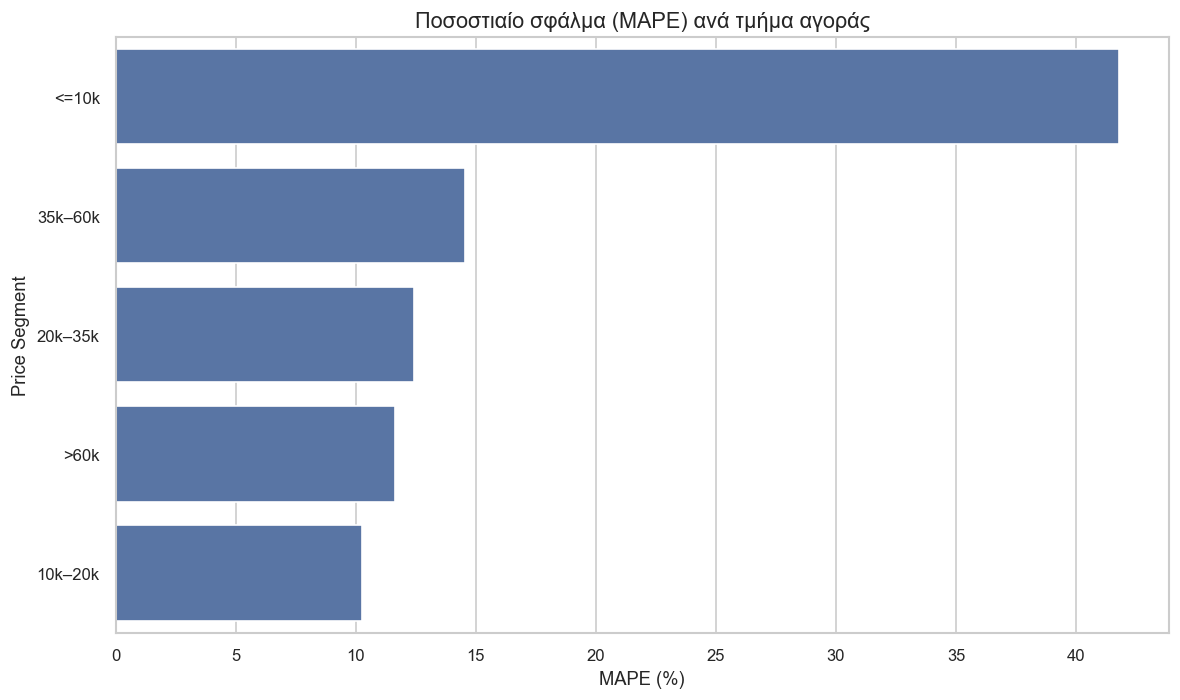

In [25]:
# ============================================================
# PLOT: MAPE ΑΝΑ PRICE SEGMENT
# ============================================================

segment_plot_df = segment_display.sort_values(by="MAPE (%)", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=segment_plot_df, x="MAPE (%)", y="Price Segment")
plt.title("Ποσοστιαίο σφάλμα (MAPE) ανά τμήμα αγοράς")
plt.xlabel("MAPE (%)")
plt.ylabel("Price Segment")

save_current_plot(PLOTS_DIR / "notebook4_price_segment_mape.png")
plt.show()

✅ Το plot αποθηκεύτηκε: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook4_price_segment_rmse.png


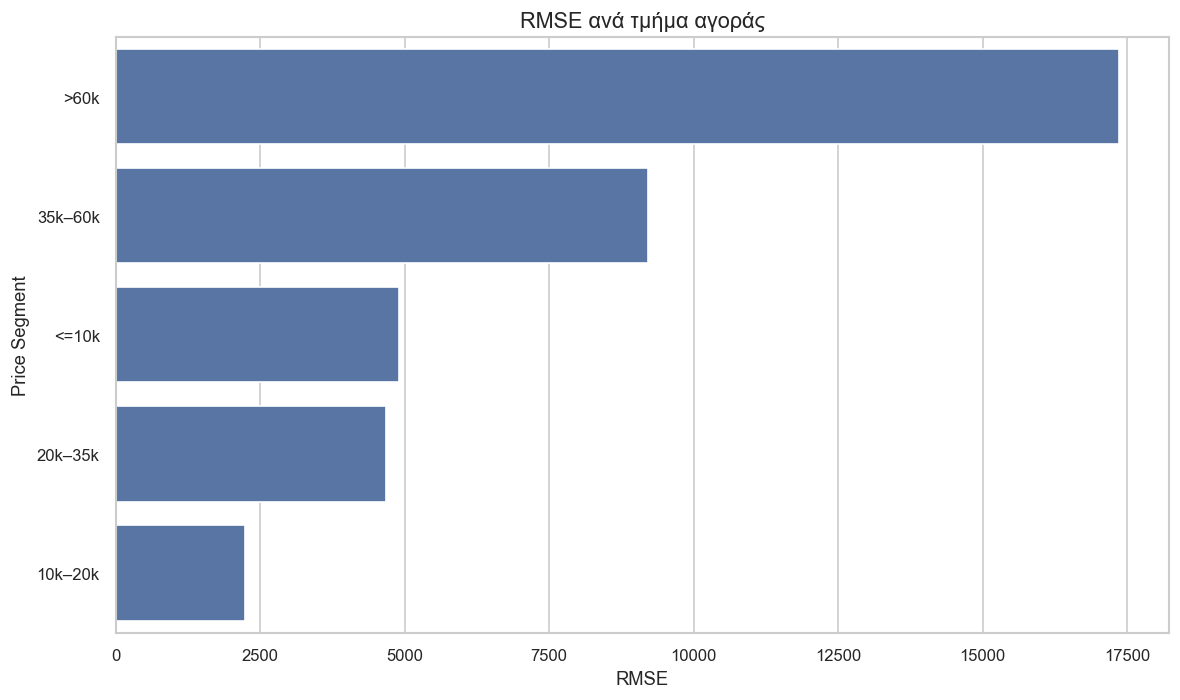

In [26]:
# ============================================================
# PLOT: RMSE ΑΝΑ PRICE SEGMENT
# ============================================================

segment_plot_df_rmse = segment_display.sort_values(by="RMSE", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=segment_plot_df_rmse, x="RMSE", y="Price Segment")
plt.title("RMSE ανά τμήμα αγοράς")
plt.xlabel("RMSE")
plt.ylabel("Price Segment")

save_current_plot(PLOTS_DIR / "notebook4_price_segment_rmse.png")
plt.show()

### Ερμηνεία της ανάλυσης ανά price segment

Η ανάλυση των σφαλμάτων ανά τμήμα αγοράς δείχνει ότι η απόδοση του μοντέλου δεν είναι ομοιόμορφη σε όλο το εύρος τιμών.

Ειδικότερα, το μοντέλο εμφανίζει διαφοροποιήσεις ως προς:

- το απόλυτο σφάλμα,
- το τετραγωνικό σφάλμα,
- και το ποσοστιαίο σφάλμα ανά segment.

Το αποτέλεσμα αυτό είναι εύλογο, καθώς τα διαφορετικά τμήματα της αγοράς μεταχειρισμένων αυτοκινήτων χαρακτηρίζονται από:

- διαφορετικό βαθμό ετερογένειας,
- διαφορετική πυκνότητα παρατηρήσεων,
- και ενδεχομένως διαφορετικούς μη παρατηρούμενους παράγοντες τιμολόγησης.

Συνεπώς, ενώ το μοντέλο εμφανίζει ισχυρή συνολική επίδοση στο πλήρες test set, η τοπική του συμπεριφορά διαφοροποιείται αισθητά όταν εξετάζεται σε επιμέρους price segments.

## Ανάλυση Σφαλμάτων Ανά Καύσιμο

Στην παρούσα ενότητα εξετάζεται η απόδοση του μοντέλου ανά κατηγορία καυσίμου.

Η ανάλυση αυτή είναι ιδιαίτερα σημαντική, καθώς οι διαφορετικοί τύποι καυσίμου αντιστοιχούν σε διακριτά τμήματα της αγοράς με διαφορετικά χαρακτηριστικά, τεχνολογίες και πρότυπα τιμολόγησης.

In [27]:
# ============================================================
# ΠΙΝΑΚΑΣ ERROR ANALYSIS ΑΝΑ ΚΑΥΣΙΜΟ
# ============================================================

fuel_col = find_first_existing_column(
    error_fuel_df,
    ["Καύσιμο", "Fuel_Type", "Fuel"],
    "error_fuel_df"
)

fuel_count_col = find_first_existing_column(
    error_fuel_df,
    ["Count", "N", "Observations"],
    "error_fuel_df"
)

fuel_mae_col = find_first_existing_column(
    error_fuel_df,
    ["MAE"],
    "error_fuel_df"
)

fuel_rmse_col = find_first_existing_column(
    error_fuel_df,
    ["RMSE"],
    "error_fuel_df"
)

fuel_r2_col = find_first_existing_column(
    error_fuel_df,
    ["R2", "R²"],
    "error_fuel_df"
)

fuel_mape_col = find_first_existing_column(
    error_fuel_df,
    ["MAPE_%", "MAPE"],
    "error_fuel_df"
)

fuel_display = error_fuel_df[
    [fuel_col, fuel_count_col, fuel_mae_col, fuel_rmse_col, fuel_r2_col, fuel_mape_col]
].copy()

fuel_display = fuel_display.rename(columns={
    fuel_col: "Καύσιμο",
    fuel_count_col: "Πλήθος Παρατηρήσεων",
    fuel_mae_col: "MAE",
    fuel_rmse_col: "RMSE",
    fuel_r2_col: "R²",
    fuel_mape_col: "MAPE (%)"
})

fuel_display = safe_round_columns(fuel_display, ["MAE", "RMSE", "MAPE (%)"], 2)
fuel_display["R²"] = pd.to_numeric(fuel_display["R²"], errors="coerce").round(4)

fuel_display = fuel_display.sort_values(by="MAPE (%)", ascending=False)

fuel_display

,Καύσιμο,Πλήθος Παρατηρήσεων,MAE,RMSE,R²,MAPE (%)
2,Ηλεκτρικό,129,"5,659.8100","8,259.2000",0.8829,17.1700
5,Πετρέλαιο,345,"3,870.4600","7,167.6600",0.8916,15.5900
3,Plug-in Hybrid Βενζίνης,212,"5,650.8300","8,047.4200",0.9363,11.7300
6,Υβριδικό Βενζίνης,289,"3,362.5800","5,412.2500",0.9532,11.5500
1,Βενζίνη,574,"3,356.4600","8,318.3500",0.9477,10.5900
4,Υβριδικό Πετρελαίου,48,"5,636.3300","7,783.2700",0.8849,9.8800
0,Plug-in Hybrid Πετρελαίου,49,"6,665.0600","9,168.5800",0.7622,9.1500


In [28]:
# ============================================================
# SAVE TABLE
# ============================================================

fuel_display.to_csv(
    NOTEBOOK4_TABLES_DIR / "notebook4_error_by_fuel_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Αποθηκεύτηκε ο πίνακας καυσίμου")

Αποθηκεύτηκε ο πίνακας καυσίμου


✅ Το plot αποθηκεύτηκε: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook4_error_by_fuel_mape.png


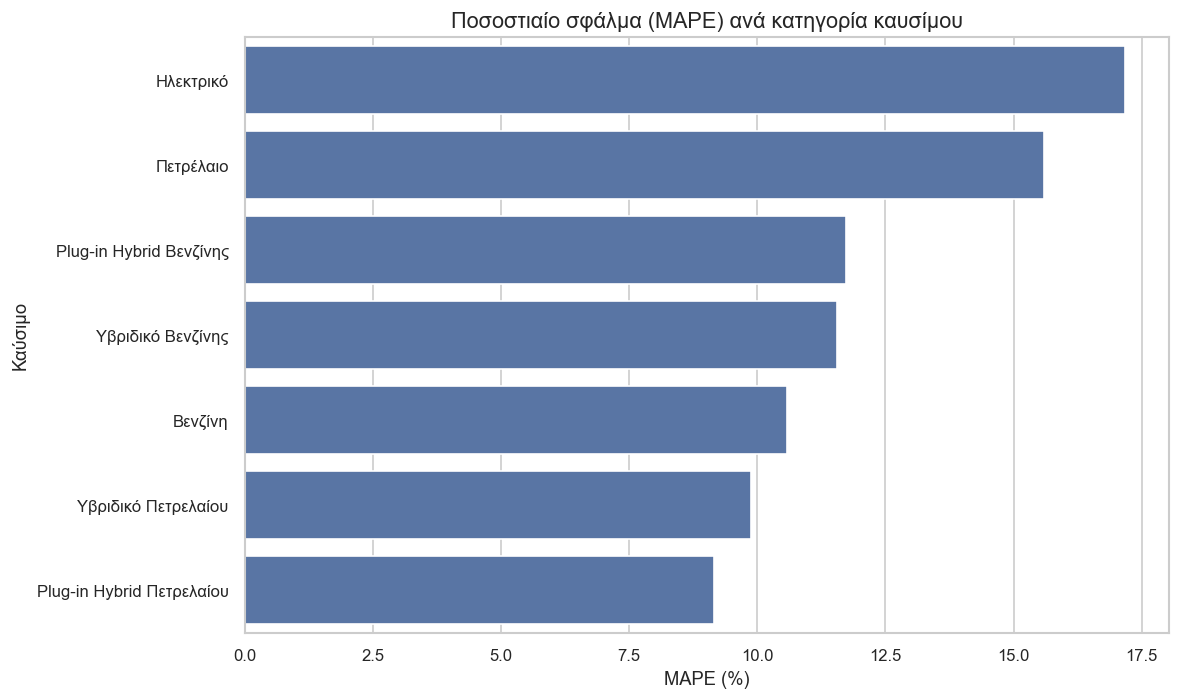

In [29]:
# ============================================================
# PLOT: MAPE ΑΝΑ ΚΑΥΣΙΜΟ
# ============================================================

plt.figure(figsize=(10, 6))
sns.barplot(data=fuel_display, x="MAPE (%)", y="Καύσιμο")

plt.title("Ποσοστιαίο σφάλμα (MAPE) ανά κατηγορία καυσίμου")
plt.xlabel("MAPE (%)")
plt.ylabel("Καύσιμο")

save_current_plot(PLOTS_DIR / "notebook4_error_by_fuel_mape.png")

plt.show()

### Ερμηνεία της ανάλυσης ανά καύσιμο

Η ανάλυση δείχνει ότι η προγνωστική απόδοση του μοντέλου διαφοροποιείται μεταξύ των κατηγοριών καυσίμου.

Το αποτέλεσμα αυτό μπορεί να ερμηνευθεί από:

- τη διαφορετική κατανομή των δεδομένων ανά κατηγορία,
- την ύπαρξη διαφορετικών τεχνολογικών χαρακτηριστικών,
- και τη διαφορετική δυναμική τιμολόγησης κάθε υποαγοράς.

Συνεπώς, το μοντέλο φαίνεται να αποδίδει καλύτερα σε ορισμένες κατηγορίες καυσίμου σε σχέση με άλλες, γεγονός που υποδεικνύει ότι η αγορά δεν είναι ομοιογενής ως προς αυτό το χαρακτηριστικό.

## Ανάλυση Σφαλμάτων Ανά Έτος Εγγραφής

Η ανάλυση ανά έτος εγγραφής επιτρέπει την εξέταση της προγνωστικής απόδοσης του μοντέλου σε σχέση με την ηλικία των οχημάτων.

Η χρονική διάσταση είναι ιδιαίτερα σημαντική στην αγορά μεταχειρισμένων αυτοκινήτων, καθώς επηρεάζει:

- την απόσβεση αξίας,
- την τεχνολογική απαξίωση,
- και τη συνολική ζήτηση.

In [30]:
# ============================================================
# ΠΙΝΑΚΑΣ ERROR ANALYSIS ΑΝΑ ΕΤΟΣ ΕΓΓΡΑΦΗΣ
# ============================================================

year_col = find_first_existing_column(
    error_year_df,
    ["Εγγραφή", "Registration_Year", "Year"],
    "error_year_df"
)

year_count_col = find_first_existing_column(
    error_year_df,
    ["Count", "N", "Observations"],
    "error_year_df"
)

year_mae_col = find_first_existing_column(
    error_year_df,
    ["MAE"],
    "error_year_df"
)

year_rmse_col = find_first_existing_column(
    error_year_df,
    ["RMSE"],
    "error_year_df"
)

year_r2_col = find_first_existing_column(
    error_year_df,
    ["R2", "R²"],
    "error_year_df"
)

year_mape_col = find_first_existing_column(
    error_year_df,
    ["MAPE_%", "MAPE"],
    "error_year_df"
)

year_display = error_year_df[
    [year_col, year_count_col, year_mae_col, year_rmse_col, year_r2_col, year_mape_col]
].copy()

year_display = year_display.rename(columns={
    year_col: "Έτος Εγγραφής",
    year_count_col: "Πλήθος Παρατηρήσεων",
    year_mae_col: "MAE",
    year_rmse_col: "RMSE",
    year_r2_col: "R²",
    year_mape_col: "MAPE (%)"
})

year_display = safe_round_columns(year_display, ["MAE", "RMSE", "MAPE (%)"], 2)
year_display["R²"] = pd.to_numeric(year_display["R²"], errors="coerce").round(4)

year_display = year_display.sort_values(by="Έτος Εγγραφής")

year_display

,Έτος Εγγραφής,Πλήθος Παρατηρήσεων,MAE,RMSE,R²,MAPE (%)
0,2021,616,"3,319.4200","6,444.7700",0.9371,11.6900
1,2022,476,"3,960.1800","7,129.6900",0.9473,12.4600
2,2023,262,"5,464.0300","9,862.8100",0.9070,14.7200
3,2024,155,"5,769.6400","9,430.1800",0.9456,13.6800
4,2025,151,"3,530.7900","6,565.2100",0.9645,9.9600


In [31]:
# ============================================================
# SAVE TABLE
# ============================================================

year_display.to_csv(
    NOTEBOOK4_TABLES_DIR / "notebook4_error_by_registration_year_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Αποθηκεύτηκε ο πίνακας ανά έτος")

Αποθηκεύτηκε ο πίνακας ανά έτος


✅ Το plot αποθηκεύτηκε: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook4_error_by_year_mae.png


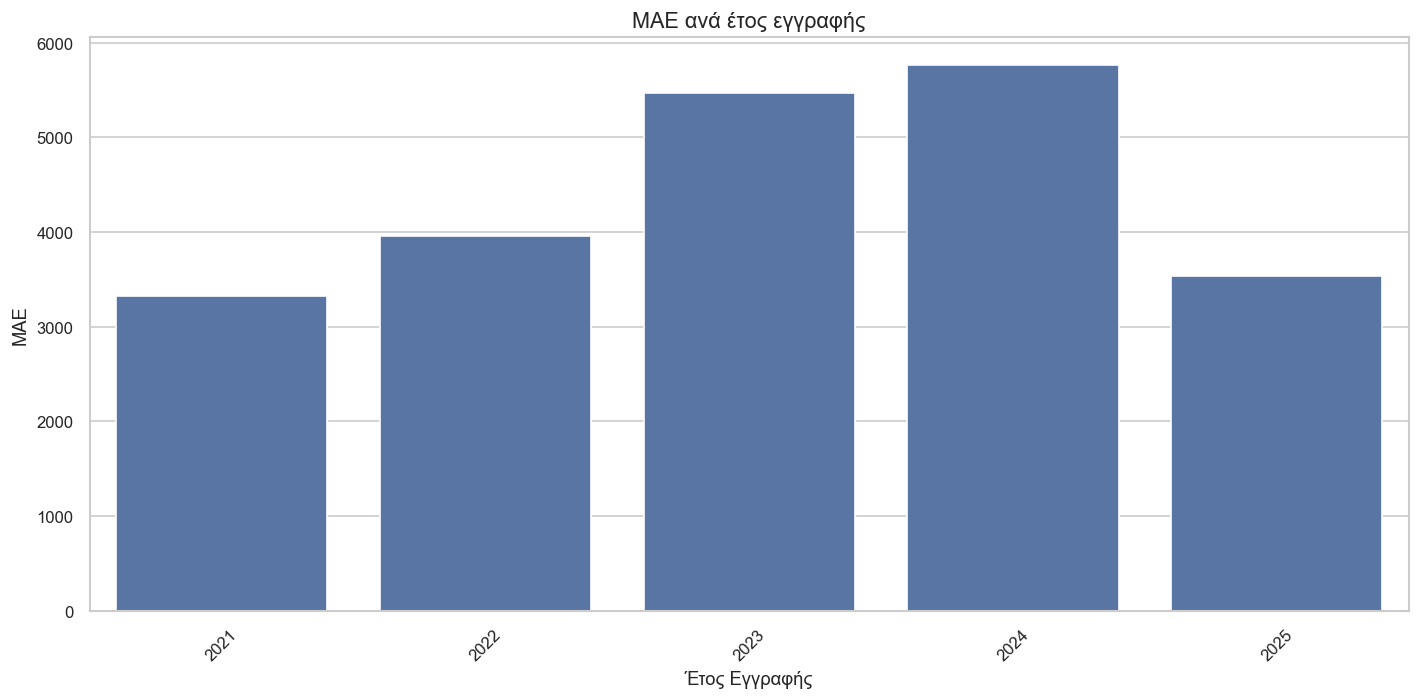

In [32]:
# ============================================================
# PLOT: MAE ΑΝΑ ΕΤΟΣ
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=year_display,
    x="Έτος Εγγραφής",
    y="MAE"
)

plt.title("MAE ανά έτος εγγραφής")
plt.xlabel("Έτος Εγγραφής")
plt.ylabel("MAE")
plt.xticks(rotation=45)

save_current_plot(PLOTS_DIR / "notebook4_error_by_year_mae.png")

plt.show()

### Ερμηνεία της ανάλυσης ανά έτος εγγραφής

Η ανάλυση δείχνει ότι η απόδοση του μοντέλου διαφοροποιείται μεταξύ παλαιότερων και νεότερων οχημάτων.

Το φαινόμενο αυτό μπορεί να ερμηνευθεί από:

- την αυξημένη ετερογένεια των παλαιότερων οχημάτων,
- τη μεγαλύτερη αβεβαιότητα στην αποτίμησή τους,
- και τη διαφορετική δυναμική τιμολόγησης των νεότερων οχημάτων.

Συνεπώς, η χρονική διάσταση αποτελεί σημαντικό παράγοντα στη δυσκολία πρόβλεψης της τιμής.

## Ανάλυση Σφαλμάτων Ανά Κατασκευαστή

Στην παρούσα ενότητα εξετάζεται η απόδοση του μοντέλου ανά κατασκευαστή.

Η ανάλυση αυτή είναι ιδιαίτερα σημαντική, καθώς οι διαφορετικοί κατασκευαστές αντιστοιχούν σε διακριτά brand segments της αγοράς, με διαφορετική τιμολογιακή στρατηγική, επίπεδο εξοπλισμού και αντίληψη αξίας από τους καταναλωτές.

In [33]:
# ============================================================
# ΠΙΝΑΚΑΣ ERROR ANALYSIS ΑΝΑ ΚΑΤΑΣΚΕΥΑΣΤΗ
# ============================================================

make_col = find_first_existing_column(
    error_make_df,
    ["Κατασκευαστής", "Make", "Brand"],
    "error_make_df"
)

make_count_col = find_first_existing_column(
    error_make_df,
    ["Count", "N", "Observations"],
    "error_make_df"
)

make_mae_col = find_first_existing_column(
    error_make_df,
    ["MAE"],
    "error_make_df"
)

make_rmse_col = find_first_existing_column(
    error_make_df,
    ["RMSE"],
    "error_make_df"
)

make_r2_col = find_first_existing_column(
    error_make_df,
    ["R2", "R²"],
    "error_make_df"
)

make_mape_col = find_first_existing_column(
    error_make_df,
    ["MAPE_%", "MAPE"],
    "error_make_df"
)

make_display = error_make_df[
    [make_col, make_count_col, make_mae_col, make_rmse_col, make_r2_col, make_mape_col]
].copy()

make_display = make_display.rename(columns={
    make_col: "Κατασκευαστής",
    make_count_col: "Πλήθος Παρατηρήσεων",
    make_mae_col: "MAE",
    make_rmse_col: "RMSE",
    make_r2_col: "R²",
    make_mape_col: "MAPE (%)"
})

make_display = safe_round_columns(make_display, ["MAE", "RMSE", "MAPE (%)"], 2)
make_display["R²"] = pd.to_numeric(make_display["R²"], errors="coerce").round(4)

make_display

,Κατασκευαστής,Πλήθος Παρατηρήσεων,MAE,RMSE,R²,MAPE (%)
0,Porsche,31,"14,501.5800","23,340.7600",0.8717,10.0500
1,BMW,135,"7,064.4500","11,820.0300",0.9152,12.3400
2,Mercedes-Benz,195,"7,270.6600","11,026.4100",0.8897,13.7100
3,LandRover,47,"8,282.0100","10,615.5800",0.8970,16.3900
4,Audi,61,"5,503.1800","8,834.2000",0.9445,10.2600
5,Volkswagen,88,"4,279.6900","7,416.5600",0.3294,16.6800
6,Ford,84,"3,430.5500","6,833.8100",0.7151,12.0200
7,Volvo,28,"3,524.0800","5,544.6500",0.5996,10.5200
8,Jeep,45,"3,678.3000","5,503.0700",0.9411,11.0300
9,MG,28,"3,377.2800","4,258.9700",0.2718,16.1400


In [34]:
# ============================================================
# ΦΙΛΤΡΟ ΓΙΑ ΑΞΙΟΠΙΣΤΑ RESULTS
# ============================================================

MIN_OBS = 30

make_filtered = make_display[
    make_display["Πλήθος Παρατηρήσεων"] >= MIN_OBS
].copy()

make_filtered.shape

(19, 6)

In [35]:
# ============================================================
# TOP ΚΑΤΑΣΚΕΥΑΣΤΕΣ
# ============================================================

top_best = make_filtered.sort_values(by="MAE", ascending=True).head(10)
top_worst = make_filtered.sort_values(by="MAE", ascending=False).head(10)

top_best, top_worst

(   Κατασκευαστής  Πλήθος Παρατηρήσεων        MAE       RMSE     R²  MAPE (%)
 21       Citroen                   88 1,663.7700 2,079.9600 0.8098   14.7400
 17           Kia                   34 1,743.1800 2,834.5600 0.8662    8.2100
 20          Fiat                   46 1,847.0900 2,431.0500 0.6962   13.7200
 19          Opel                  103 1,859.6000 2,634.9500 0.5681   11.8100
 18       Peugeot                  171 1,911.5700 2,831.9000 0.8007    9.3200
 13        Suzuki                   36 2,118.5900 3,764.8100 0.3911   10.2700
 14         Skoda                   43 2,218.9800 3,152.3800 0.7888    9.7000
 15       Hyundai                   47 2,237.5000 3,112.3700 0.7506   10.3400
 12       Renault                   36 2,555.8400 3,860.8300 0.4821   13.4300
 10        Toyota                  108 2,743.4200 4,240.2100 0.8406   11.9300,
     Κατασκευαστής  Πλήθος Παρατηρήσεων         MAE        RMSE     R²  MAPE (%)
 0         Porsche                   31 14,501.5800 23,340.7

In [37]:
# ============================================================
# SAVE TABLES
# ============================================================

make_filtered.to_csv(
    NOTEBOOK4_TABLES_DIR / "notebook4_make_filtered.csv",
    index=False,
    encoding="utf-8-sig"
)

top_best.to_csv(
    NOTEBOOK4_TABLES_DIR / "notebook4_top_best_makes.csv",
    index=False,
    encoding="utf-8-sig"
)

top_worst.to_csv(
    NOTEBOOK4_TABLES_DIR / "notebook4_top_worst_makes.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Αποθηκεύτηκαν τα make tables")

Αποθηκεύτηκαν τα make tables


✅ Το plot αποθηκεύτηκε: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook4_best_makes.png


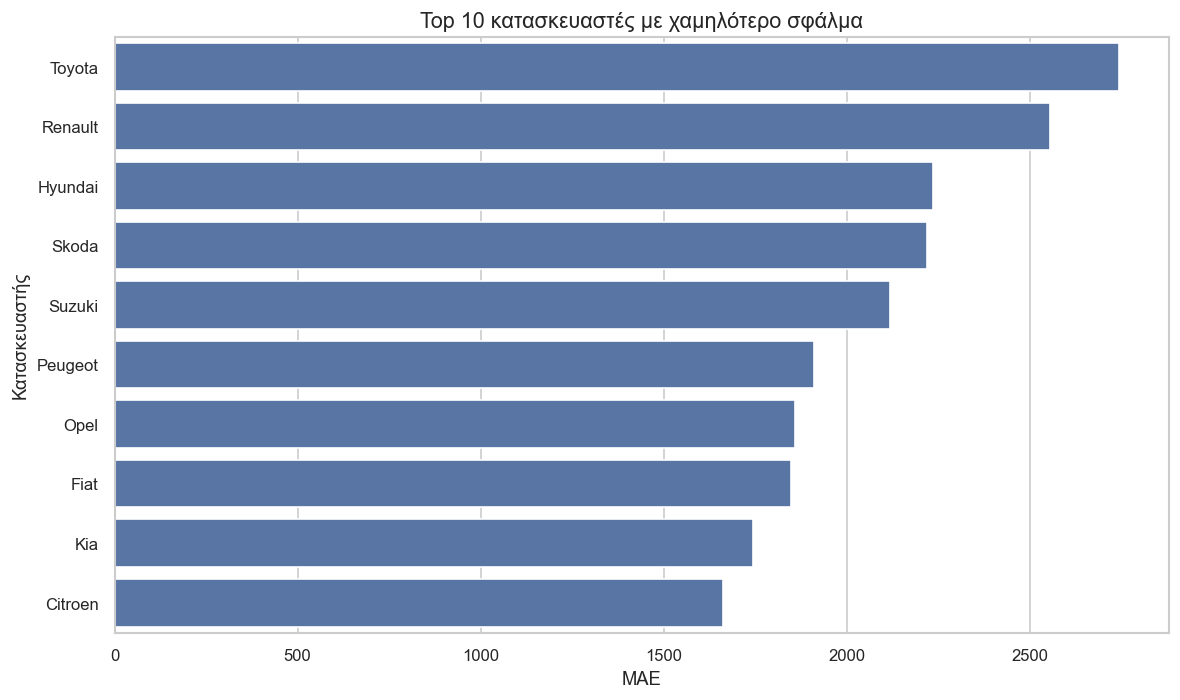

In [38]:
# ============================================================
# PLOT: BEST MAKES
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_best.sort_values(by="MAE", ascending=False),
    x="MAE",
    y="Κατασκευαστής"
)

plt.title("Top 10 κατασκευαστές με χαμηλότερο σφάλμα")
plt.xlabel("MAE")
plt.ylabel("Κατασκευαστής")

save_current_plot(PLOTS_DIR / "notebook4_best_makes.png")

plt.show()

✅ Το plot αποθηκεύτηκε: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook4_worst_makes.png


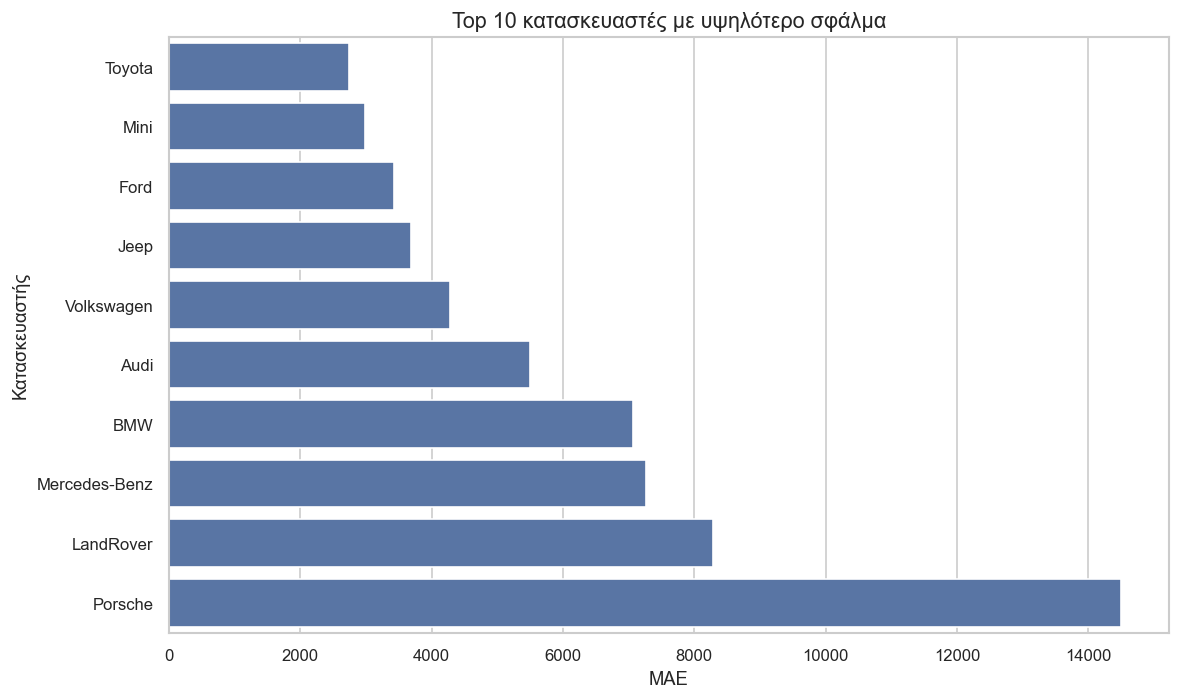

In [39]:
# ============================================================
# PLOT: WORST MAKES
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_worst.sort_values(by="MAE", ascending=True),
    x="MAE",
    y="Κατασκευαστής"
)

plt.title("Top 10 κατασκευαστές με υψηλότερο σφάλμα")
plt.xlabel("MAE")
plt.ylabel("Κατασκευαστής")

save_current_plot(PLOTS_DIR / "notebook4_worst_makes.png")

plt.show()

### Ερμηνεία της ανάλυσης ανά κατασκευαστή

Η ανάλυση δείχνει ότι η απόδοση του μοντέλου διαφοροποιείται σημαντικά μεταξύ των κατασκευαστών.

Το εύρημα αυτό μπορεί να ερμηνευθεί από:

- τη διαφορετική εμπορική τοποθέτηση των brands,
- τη διαφοροποίηση στη γκάμα μοντέλων και εκδόσεων,
- και τη διαφορετική ετερογένεια των δεδομένων ανά κατασκευαστή.

Ειδικότερα, ορισμένοι κατασκευαστές εμφανίζουν χαμηλότερο σφάλμα πρόβλεψης, γεγονός που υποδηλώνει πιο σταθερή και προβλέψιμη τιμολογιακή συμπεριφορά.

Αντίθετα, άλλοι κατασκευαστές παρουσιάζουν υψηλότερη μεταβλητότητα, καθιστώντας την πρόβλεψη της τιμής πιο απαιτητική.

## Ερμηνεία Μοντέλου με SHAP

Στην παρούσα ενότητα αξιοποιούνται τα αποτελέσματα SHAP για την ερμηνεία του τελικού μοντέλου.

Η μέθοδος SHAP επιτρέπει την αποτίμηση της σχετικής συμβολής των χαρακτηριστικών στην τελική πρόβλεψη, διευκολύνοντας την κατανόηση των σημαντικότερων παραγόντων που επηρεάζουν την τιμή ενός μεταχειρισμένου αυτοκινήτου.

Στο πλαίσιο της παρούσας ανάλυσης χρησιμοποιούνται:
- τα **grouped SHAP importance results**, τα οποία συνοψίζουν τη σημασία ομάδων χαρακτηριστικών,
- και τα **transformed SHAP importance results**, τα οποία επιτρέπουν τη λεπτομερέστερη εξέταση των σημαντικότερων επιμέρους χαρακτηριστικών.

In [42]:
# ============================================================
# ΦΟΡΤΩΣΗ SHAP ΑΡΧΕΙΩΝ
# ============================================================

shap_transformed_path = DATA_PROCESSED_DIR / "notebook3_transformed_shap_importance.csv"
shap_grouped_path = DATA_PROCESSED_DIR / "notebook3_grouped_shap_importance.csv"

shap_transformed_df = pd.read_csv(shap_transformed_path)
shap_grouped_df = pd.read_csv(shap_grouped_path)

print("Τα SHAP αρχεία φορτώθηκαν επιτυχώς.")
print("\nΣτήλες transformed SHAP:")
print(shap_transformed_df.columns.tolist())

print("\nΣτήλες grouped SHAP:")
print(shap_grouped_df.columns.tolist())

Τα SHAP αρχεία φορτώθηκαν επιτυχώς.

Στήλες transformed SHAP:
['Transformed_Feature', 'Mean_Abs_SHAP']

Στήλες grouped SHAP:
['Feature_Group', 'Mean_Abs_SHAP']


In [44]:
# ============================================================
# ΠΙΝΑΚΑΣ GROUPED SHAP IMPORTANCE
# ============================================================

group_col = find_first_existing_column(
    shap_grouped_df,
    ["Feature_Group", "feature_group", "Group", "Feature", "feature"],
    "shap_grouped_df"
)

group_importance_col = find_first_existing_column(
    shap_grouped_df,
    ["Mean_Abs_SHAP", "mean_abs_shap", "Mean_SHAP"],
    "shap_grouped_df"
)

shap_grouped_display = shap_grouped_df[[group_col, group_importance_col]].copy()

shap_grouped_display = shap_grouped_display.rename(columns={
    group_col: "Ομάδα Χαρακτηριστικών",
    group_importance_col: "SHAP Importance"
})

shap_grouped_display["SHAP Importance"] = pd.to_numeric(
    shap_grouped_display["SHAP Importance"], errors="coerce"
).round(6)

shap_grouped_display = shap_grouped_display.sort_values(
    by="SHAP Importance", ascending=False
).reset_index(drop=True)

shap_grouped_display

,Ομάδα Χαρακτηριστικών,SHAP Importance
0,Ιπποδύναμη,"10,166.4310"
1,Κυβικά,"8,347.4830"
2,Κατασκευαστής,"3,648.9316"
3,Χιλιόμετρα,"2,495.4970"
4,Τύπος,"1,535.6069"
5,Ηλικία,"1,495.4739"
6,Καύσιμο,"1,270.5637"
7,Μετάδοση,960.7883
8,Περιοχή,583.4295


In [45]:
# ============================================================
# ΑΠΟΘΗΚΕΥΣΗ GROUPED SHAP TABLE
# ============================================================

shap_grouped_display.to_csv(
    NOTEBOOK4_TABLES_DIR / "notebook4_grouped_shap_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Αποθηκεύτηκε ο grouped SHAP πίνακας.")

Αποθηκεύτηκε ο grouped SHAP πίνακας.


✅ Το plot αποθηκεύτηκε: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook4_grouped_shap_importance.png


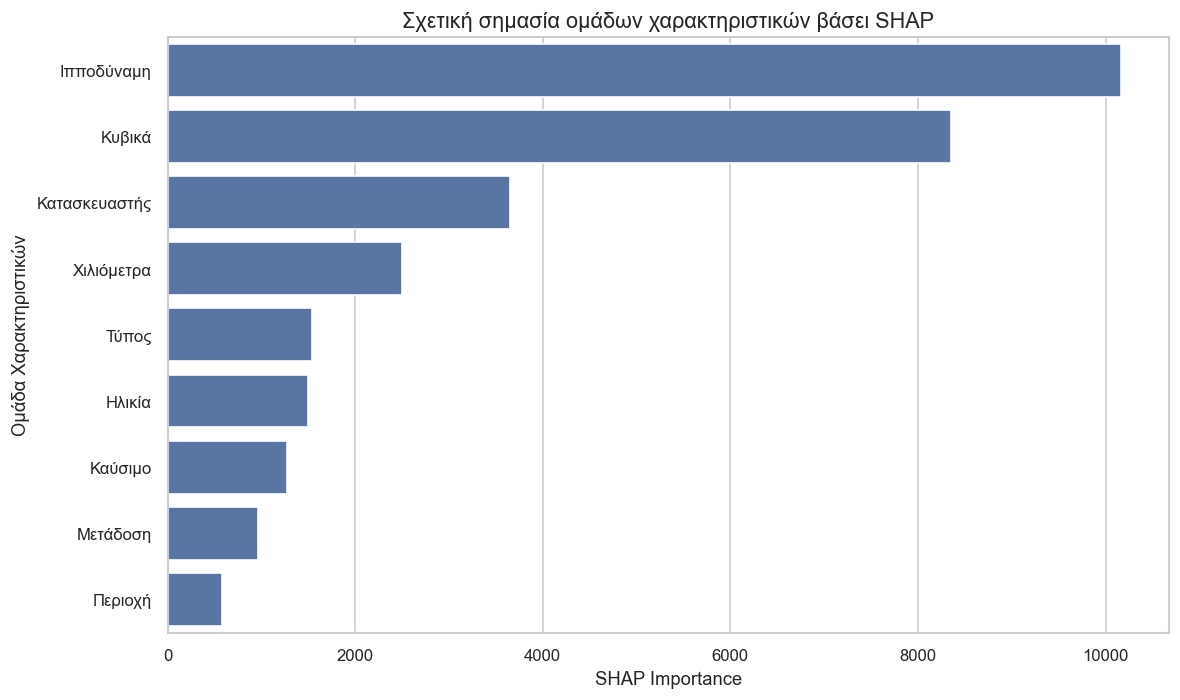

In [46]:
# ============================================================
# PLOT: GROUPED SHAP IMPORTANCE
# ============================================================

plt.figure(figsize=(10, 6))
sns.barplot(data=shap_grouped_display, x="SHAP Importance", y="Ομάδα Χαρακτηριστικών")

plt.title("Σχετική σημασία ομάδων χαρακτηριστικών βάσει SHAP")
plt.xlabel("SHAP Importance")
plt.ylabel("Ομάδα Χαρακτηριστικών")

save_current_plot(PLOTS_DIR / "notebook4_grouped_shap_importance.png")
plt.show()

In [47]:
# ============================================================
# ΠΙΝΑΚΑΣ TRANSFORMED SHAP IMPORTANCE
# ============================================================

feature_col = find_first_existing_column(
    shap_transformed_df,
    ["Feature", "feature", "Transformed_Feature"],
    "shap_transformed_df"
)

feature_importance_col = find_first_existing_column(
    shap_transformed_df,
    ["Mean_Abs_SHAP", "Importance", "importance", "Mean_SHAP", "mean_abs_shap"],
    "shap_transformed_df"
)

shap_feature_display = shap_transformed_df[[feature_col, feature_importance_col]].copy()

shap_feature_display = shap_feature_display.rename(columns={
    feature_col: "Χαρακτηριστικό",
    feature_importance_col: "SHAP Importance"
})

shap_feature_display["SHAP Importance"] = pd.to_numeric(
    shap_feature_display["SHAP Importance"], errors="coerce"
).round(6)

shap_feature_display = shap_feature_display.sort_values(
    by="SHAP Importance", ascending=False
).reset_index(drop=True)

shap_feature_display.head(15)

,Χαρακτηριστικό,SHAP Importance
0,num__Ιπποδύναμη,"10,166.4310"
1,num__Κυβικά,"8,347.4830"
2,num__Χιλιόμετρα,"2,495.4970"
3,cat__Κατασκευαστής_Mercedes-Benz,"1,570.9751"
4,num__Ηλικία,"1,495.4739"
5,cat__Κατασκευαστής_Porsche,567.3360
6,cat__Μετάδοση_Χειροκίνητο,537.7084
7,cat__Καύσιμο_Πετρέλαιο,438.8505
8,cat__Μετάδοση_Αυτόματο,422.8858
9,cat__Κατασκευαστής_LandRover,400.0929


In [48]:
# ============================================================
# ΑΠΟΘΗΚΕΥΣΗ TOP FEATURES SHAP TABLE
# ============================================================

shap_feature_display.to_csv(
    NOTEBOOK4_TABLES_DIR / "notebook4_transformed_shap_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Αποθηκεύτηκε ο transformed SHAP πίνακας.")

Αποθηκεύτηκε ο transformed SHAP πίνακας.


✅ Το plot αποθηκεύτηκε: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook4_top15_shap_features.png


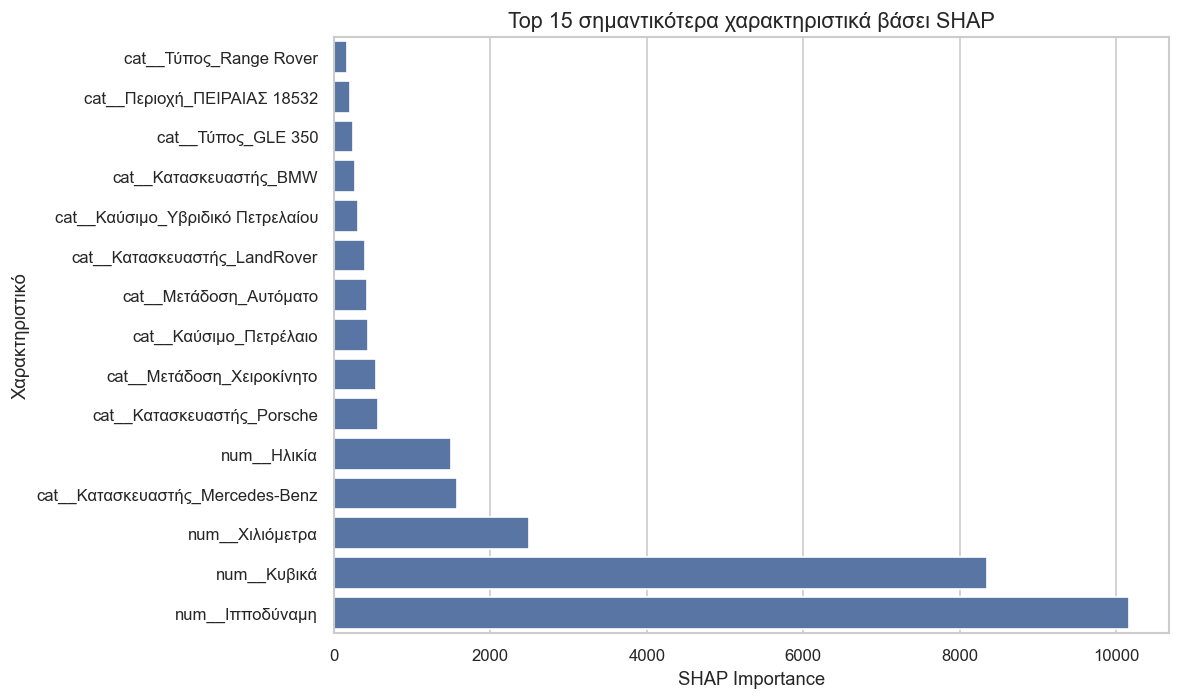

In [49]:
# ============================================================
# PLOT: TOP 15 SHAP FEATURES
# ============================================================

top_15_shap_features = shap_feature_display.head(15).copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_15_shap_features.sort_values(by="SHAP Importance", ascending=True),
    x="SHAP Importance",
    y="Χαρακτηριστικό"
)

plt.title("Top 15 σημαντικότερα χαρακτηριστικά βάσει SHAP")
plt.xlabel("SHAP Importance")
plt.ylabel("Χαρακτηριστικό")

save_current_plot(PLOTS_DIR / "notebook4_top15_shap_features.png")
plt.show()

### Ερμηνεία των αποτελεσμάτων SHAP

Η ανάλυση SHAP δείχνει ότι η τιμή των μεταχειρισμένων αυτοκινήτων επηρεάζεται κυρίως από έναν συνδυασμό τεχνικών, χρηστικών και εμπορικών χαρακτηριστικών.

Ειδικότερα, οι σημαντικότερες ομάδες χαρακτηριστικών σχετίζονται με:

- την ισχύ και τον κυβισμό του οχήματος,
- τα στοιχεία χρήσης, όπως τα χιλιόμετρα,
- τη χρονολογική του τοποθέτηση μέσω της ηλικίας,
- και την εμπορική ταυτότητα του οχήματος, όπως ο κατασκευαστής και ο τύπος.

Το εύρημα αυτό είναι πλήρως συμβατό με τον τρόπο λειτουργίας της αγοράς μεταχειρισμένων αυτοκινήτων, όπου η τελική τιμή διαμορφώνεται από την αλληλεπίδραση μεταξύ παλαιότητας, τεχνικής απόδοσης, φθοράς, κατηγορίας οχήματος και brand positioning.

Συνεπώς, το τελικό μοντέλο δεν λειτουργεί ως ένα αδιαφανές «μαύρο κουτί», αλλά στηρίζεται σε παράγοντες που είναι ερμηνεύσιμοι και οικονομικά εύλογοι.

## Τελική Επιλογή Μοντέλου

Με βάση τα αποτελέσματα της συνολικής αξιολόγησης, της σύγκρισης tuned και untuned εκδόσεων, καθώς και της ανάλυσης ερμηνευσιμότητας, το **XGBoost (untuned)** επιλέγεται ως το τελικό μοντέλο της παρούσας μελέτης.

Η επιλογή αυτή βασίζεται κυρίως στα εξής:

- παρουσιάζει την καλύτερη συνολική επίδοση ως προς το **RMSE**,
- εμφανίζει πολύ υψηλή τιμή **R²**,
- διατηρεί ισχυρή ικανότητα γενίκευσης στο test set,
- και συνοδεύεται από ερμηνευσιμότητα που είναι συμβατή με την οικονομική και αγοραία λογική της τιμολόγησης μεταχειρισμένων οχημάτων.

In [50]:
# ============================================================
# ΔΗΜΙΟΥΡΓΙΑ ΤΕΛΙΚΟΥ ΠΙΝΑΚΑ ΒΑΣΙΚΩΝ ΕΥΡΗΜΑΤΩΝ
# ============================================================

key_findings_df = pd.DataFrame({
    "Ενότητα": [
        "Συνολική σύγκριση μοντέλων",
        "Τελικό μοντέλο",
        "Hyperparameter tuning",
        "Price segment analysis",
        "Fuel-type analysis",
        "Registration-year analysis",
        "Make-level analysis",
        "SHAP interpretability"
    ],
    "Κύριο εύρημα": [
        "Τα ensemble tree-based μοντέλα υπερέχουν των baseline και γραμμικών προσεγγίσεων.",
        "Το untuned XGBoost εμφανίζει την καλύτερη συνολική επίδοση.",
        "Το tuning δεν βελτίωσε καθαρά το RMSE, αν και σε ορισμένες περιπτώσεις βελτίωσε άλλες μετρικές.",
        "Η απόδοση διαφοροποιείται αισθητά ανά τμήμα αγοράς.",
        "Η επίδοση δεν είναι ομοιόμορφη μεταξύ των κατηγοριών καυσίμου.",
        "Η προγνωστική συμπεριφορά μεταβάλλεται ανά έτος εγγραφής.",
        "Η απόδοση διαφέρει ανά κατασκευαστή, ακόμη και μετά από φίλτρο ελάχιστου πλήθους.",
        "Οι σημαντικότερες ομάδες χαρακτηριστικών συμφωνούν με τη λογική της αγοράς."
    ],
    "Ερμηνεία": [
        "Η αγορά μεταχειρισμένων αυτοκινήτων παρουσιάζει μη γραμμικές σχέσεις και σύνθετες αλληλεπιδράσεις χαρακτηριστικών.",
        "Το μοντέλο αποτυπώνει καλύτερα τη σύνθετη δομή των δεδομένων και παρουσιάζει ισχυρή γενίκευση.",
        "Η αυξημένη πολυπλοκότητα ρύθμισης δεν εγγυάται απαραίτητα καλύτερη συνολική προγνωστική επίδοση.",
        "Η τοπική δυσκολία πρόβλεψης εξαρτάται από την ετερογένεια και την πυκνότητα κάθε segment.",
        "Κάθε κατηγορία καυσίμου αντιστοιχεί σε διακριτή τεχνολογική και αγοραία υποκατηγορία.",
        "Η ηλικία και η χρονική τοποθέτηση του οχήματος επηρεάζουν ουσιαστικά την αποτίμηση.",
        "Η εμπορική ταυτότητα του brand σχετίζεται με διαφορετικά πρότυπα τιμολόγησης.",
        "Οι τεχνικές, χρηστικές και εμπορικές μεταβλητές αποτελούν τους βασικούς άξονες διαμόρφωσης της τιμής."
    ]
})

key_findings_df

,Ενότητα,Κύριο εύρημα,Ερμηνεία
0,Συνολική σύγκριση μοντέλων,Τα ensemble tree-based μοντέλα υπερέχουν των baseline και γραμμικών προσεγγίσεων.,Η αγορά μεταχειρισμένων αυτοκινήτων παρουσιάζει μη γραμμικές σχέσεις και σύνθετες αλληλεπιδράσεις χαρακτηριστικών.
1,Τελικό μοντέλο,Το untuned XGBoost εμφανίζει την καλύτερη συνολική επίδοση.,Το μοντέλο αποτυπώνει καλύτερα τη σύνθετη δομή των δεδομένων και παρουσιάζει ισχυρή γενίκευση.
2,Hyperparameter tuning,"Το tuning δεν βελτίωσε καθαρά το RMSE, αν και σε ορισμένες περιπτώσεις βελτίωσε άλλες μετρικές.",Η αυξημένη πολυπλοκότητα ρύθμισης δεν εγγυάται απαραίτητα καλύτερη συνολική προγνωστική επίδοση.
3,Price segment analysis,Η απόδοση διαφοροποιείται αισθητά ανά τμήμα αγοράς.,Η τοπική δυσκολία πρόβλεψης εξαρτάται από την ετερογένεια και την πυκνότητα κάθε segment.
4,Fuel-type analysis,Η επίδοση δεν είναι ομοιόμορφη μεταξύ των κατηγοριών καυσίμου.,Κάθε κατηγορία καυσίμου αντιστοιχεί σε διακριτή τεχνολογική και αγοραία υποκατηγορία.
5,Registration-year analysis,Η προγνωστική συμπεριφορά μεταβάλλεται ανά έτος εγγραφής.,Η ηλικία και η χρονική τοποθέτηση του οχήματος επηρεάζουν ουσιαστικά την αποτίμηση.
6,Make-level analysis,"Η απόδοση διαφέρει ανά κατασκευαστή, ακόμη και μετά από φίλτρο ελάχιστου πλήθους.",Η εμπορική ταυτότητα του brand σχετίζεται με διαφορετικά πρότυπα τιμολόγησης.
7,SHAP interpretability,Οι σημαντικότερες ομάδες χαρακτηριστικών συμφωνούν με τη λογική της αγοράς.,"Οι τεχνικές, χρηστικές και εμπορικές μεταβλητές αποτελούν τους βασικούς άξονες διαμόρφωσης της τιμής."


In [51]:
# ============================================================
# ΑΠΟΘΗΚΕΥΣΗ ΠΙΝΑΚΑ ΒΑΣΙΚΩΝ ΕΥΡΗΜΑΤΩΝ
# ============================================================

key_findings_df.to_csv(
    NOTEBOOK4_TABLES_DIR / "notebook4_key_findings_table.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Αποθηκεύτηκε ο πίνακας βασικών ευρημάτων.")

Αποθηκεύτηκε ο πίνακας βασικών ευρημάτων.


## Συνολικά Συμπεράσματα

Η παρούσα ανάλυση έδειξε ότι η πρόβλεψη της τιμής μεταχειρισμένων αυτοκινήτων στην Αττική μπορεί να πραγματοποιηθεί με υψηλή ακρίβεια μέσω σύγχρονων μεθόδων μηχανικής μάθησης, υπό την προϋπόθεση ότι προηγείται προσεκτικός καθαρισμός δεδομένων, οργανωμένη επιλογή χαρακτηριστικών και συστηματική αξιολόγηση μοντέλων.

Τα βασικά συμπεράσματα της μελέτης είναι τα εξής:

- τα tree-based ensemble μοντέλα αποδείχθηκαν σημαντικά αποτελεσματικότερα από απλούστερες προσεγγίσεις,
- το **untuned XGBoost** επιλέχθηκε ως τελικό μοντέλο λόγω της ισχυρότερης συνολικής επίδοσης,
- η διαδικασία hyperparameter tuning δεν οδήγησε σε σαφή βελτίωση της βασικής μετρικής RMSE,
- η απόδοση του μοντέλου διαφοροποιείται αισθητά ανά τμήμα αγοράς και ανά επιμέρους χαρακτηριστικά,
- και οι μεταβλητές που αναδείχθηκαν ως σημαντικότερες μέσω SHAP είναι πλήρως συμβατές με τη λογική της πραγματικής αγοράς μεταχειρισμένων αυτοκινήτων.

Συνολικά, τα αποτελέσματα υποστηρίζουν ότι η συνδυαστική χρήση αναλυτικού workflow, predictive modeling και ερμηνευσιμότητας μπορεί να προσφέρει μια τεκμηριωμένη και πρακτικά χρήσιμη προσέγγιση για τη μελέτη της αγοράς μεταχειρισμένων οχημάτων.

## Περιορισμοί της Μελέτης

Παρά τη θετική συνολική εικόνα των αποτελεσμάτων, η παρούσα μελέτη παρουσιάζει ορισμένους περιορισμούς που πρέπει να λαμβάνονται υπόψη κατά την ερμηνεία των ευρημάτων.

Πρώτον, το dataset βασίζεται σε **δεδομένα αγγελιών** και όχι σε τελικές πραγματικές συναλλαγές. Κατά συνέπεια, οι αναγραφόμενες τιμές ενδέχεται να διαφέρουν από τις τελικές τιμές πώλησης.

Δεύτερον, η ανάλυση περιορίζεται **γεωγραφικά στην Αττική**, γεγονός που σημαίνει ότι τα αποτελέσματα δεν μπορούν να γενικευθούν αυτόματα στο σύνολο της ελληνικής αγοράς.

Τρίτον, είναι πιθανό να απουσιάζουν ορισμένα **ποιοτικά ή ειδικά χαρακτηριστικά** που επηρεάζουν ουσιαστικά την τιμή, όπως η ακριβής έκδοση εξοπλισμού, το ιστορικό συντήρησης, η κατάσταση αμαξώματος ή πιο εξειδικευμένα brand-specific στοιχεία.

Τέταρτον, ορισμένες υποκατηγορίες της αγοράς εμφανίζουν μικρότερο πλήθος παρατηρήσεων, γεγονός που μπορεί να οδηγεί σε λιγότερο σταθερές εκτιμήσεις όταν η ανάλυση γίνεται σε πολύ εξειδικευμένα segments.

Τέλος, η αγορά μεταχειρισμένων αυτοκινήτων είναι δυναμική και επηρεάζεται από μακροοικονομικούς, τεχνολογικούς και θεσμικούς παράγοντες, οι οποίοι ενδέχεται να μεταβάλλουν τη συμπεριφορά των τιμών στον χρόνο.

## Προτάσεις για Μελλοντική Έρευνα

Με βάση τα αποτελέσματα και τους περιορισμούς της παρούσας μελέτης, προτείνονται οι ακόλουθες κατευθύνσεις για μελλοντική έρευνα:

- εμπλουτισμός του dataset με επιπλέον ποιοτικά χαρακτηριστικά και λεπτομερέστερα τεχνικά γνωρίσματα,
- ενσωμάτωση χρονικής διάστασης και ανάπτυξη time-aware μοντέλων,
- διερεύνηση της χρήσης ξεχωριστών μοντέλων ανά κύριο τμήμα αγοράς ή ανά κατηγορία καυσίμου,
- αξιοποίηση δεδομένων πραγματικών συναλλαγών, εφόσον καταστούν διαθέσιμα,
- και επέκταση της ανάλυσης σε ευρύτερη γεωγραφική κλίμακα πέραν της Αττικής.

Οι κατευθύνσεις αυτές θα μπορούσαν να ενισχύσουν περαιτέρω τόσο την προγνωστική ακρίβεια όσο και την ερμηνευτική αξία της ανάλυσης.

## Παραγωγή Τελικών Αρχείων Εξόδου

Στο τελευταίο βήμα συγκεντρώνονται σε έναν συνοπτικό πίνακα τα βασικά outputs του notebook, ώστε να είναι άμεσα διαθέσιμα για χρήση στη συγγραφή της πτυχιακής, σε παραρτήματα, σε παρουσιάσεις ή σε μελλοντική αξιοποίηση μέσω Streamlit.

In [52]:
# ============================================================
# ΔΗΜΙΟΥΡΓΙΑ ΤΕΛΙΚΟΥ INVENTORY ΤΩΝ OUTPUTS
# ============================================================

generated_outputs_df = pd.DataFrame({
    "Τύπος Output": [
        "CSV Table", "CSV Table", "CSV Table", "CSV Table", "CSV Table",
        "CSV Table", "CSV Table", "CSV Table", "CSV Table",
        "Plot", "Plot", "Plot", "Plot", "Plot",
        "Plot", "Plot", "Plot", "Plot", "Plot", "Plot"
    ],
    "Όνομα Αρχείου": [
        "notebook4_model_comparison_summary.csv",
        "notebook4_final_model_results_summary.csv",
        "notebook4_tuned_vs_untuned_summary.csv",
        "notebook4_price_segment_performance.csv",
        "notebook4_error_by_fuel_summary.csv",
        "notebook4_error_by_registration_year_summary.csv",
        "notebook4_make_filtered.csv",
        "notebook4_grouped_shap_summary.csv",
        "notebook4_key_findings_table.csv",
        "notebook4_model_comparison_rmse.png",
        "notebook4_model_comparison_mae.png",
        "notebook4_final_models_rmse.png",
        "notebook4_final_models_r2.png",
        "notebook4_tuning_rmse_comparison.png",
        "notebook4_tuning_mae_comparison.png",
        "notebook4_price_segment_mape.png",
        "notebook4_price_segment_rmse.png",
        "notebook4_error_by_fuel_mape.png",
        "notebook4_error_by_year_mae.png",
        "notebook4_grouped_shap_importance.png"
    ],
    "Περιγραφή": [
        "Συνοπτικός πίνακας αρχικής σύγκρισης μοντέλων",
        "Τελικός πίνακας αποτελεσμάτων μοντέλων",
        "Σύγκριση tuned και untuned εκδόσεων",
        "Απόδοση ανά price segment",
        "Ανάλυση σφαλμάτων ανά καύσιμο",
        "Ανάλυση σφαλμάτων ανά έτος εγγραφής",
        "Ανάλυση σφαλμάτων ανά κατασκευαστή",
        "Πίνακας grouped SHAP importance",
        "Πίνακας βασικών ευρημάτων",
        "Γράφημα RMSE της αρχικής σύγκρισης",
        "Γράφημα MAE της αρχικής σύγκρισης",
        "Γράφημα RMSE τελικών μοντέλων",
        "Γράφημα R² τελικών μοντέλων",
        "Γράφημα RMSE tuned vs untuned",
        "Γράφημα MAE tuned vs untuned",
        "Γράφημα MAPE ανά price segment",
        "Γράφημα RMSE ανά price segment",
        "Γράφημα MAPE ανά καύσιμο",
        "Γράφημα MAE ανά έτος εγγραφής",
        "Γράφημα grouped SHAP importance"
    ]
})

generated_outputs_df

,Τύπος Output,Όνομα Αρχείου,Περιγραφή
0,CSV Table,notebook4_model_comparison_summary.csv,Συνοπτικός πίνακας αρχικής σύγκρισης μοντέλων
1,CSV Table,notebook4_final_model_results_summary.csv,Τελικός πίνακας αποτελεσμάτων μοντέλων
2,CSV Table,notebook4_tuned_vs_untuned_summary.csv,Σύγκριση tuned και untuned εκδόσεων
3,CSV Table,notebook4_price_segment_performance.csv,Απόδοση ανά price segment
4,CSV Table,notebook4_error_by_fuel_summary.csv,Ανάλυση σφαλμάτων ανά καύσιμο
5,CSV Table,notebook4_error_by_registration_year_summary.csv,Ανάλυση σφαλμάτων ανά έτος εγγραφής
6,CSV Table,notebook4_make_filtered.csv,Ανάλυση σφαλμάτων ανά κατασκευαστή
7,CSV Table,notebook4_grouped_shap_summary.csv,Πίνακας grouped SHAP importance
8,CSV Table,notebook4_key_findings_table.csv,Πίνακας βασικών ευρημάτων
9,Plot,notebook4_model_comparison_rmse.png,Γράφημα RMSE της αρχικής σύγκρισης


In [53]:
# ============================================================
# ΑΠΟΘΗΚΕΥΣΗ OUTPUT INVENTORY
# ============================================================

generated_outputs_df.to_csv(
    NOTEBOOK4_TABLES_DIR / "notebook4_generated_outputs_inventory.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Αποθηκεύτηκε ο πίνακας inventory των outputs.")

Αποθηκεύτηκε ο πίνακας inventory των outputs.


In [54]:
# ============================================================
# ΤΕΛΙΚΟ ΜΗΝΥΜΑ ΟΛΟΚΛΗΡΩΣΗΣ
# ============================================================

print("Ολοκληρώθηκε επιτυχώς το notebook: 04_Final_Results_Thesis_Reporting.ipynb")
print(f"Τα plots αποθηκεύτηκαν στον φάκελο: {PLOTS_DIR}")
print(f"Οι πίνακες αποθηκεύτηκαν στον φάκελο: {NOTEBOOK4_TABLES_DIR}")

Ολοκληρώθηκε επιτυχώς το notebook: 04_Final_Results_Thesis_Reporting.ipynb
Τα plots αποθηκεύτηκαν στον φάκελο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots
Οι πίνακες αποθηκεύτηκαν στον φάκελο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook4_outputs
